In [1]:
import sys
print(sys.executable)

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Scripts\python.exe


In [2]:
from pyspark.sql import SparkSession

In [3]:
spark=SparkSession.builder \
    .appName("Retail Sales Analytics") \
    .getOrCreate()

print("Spark created successfully")
print("Spark version",spark.version)

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark created successfully
Spark version 4.2.0


## Bronze Layer
The Bronze layer contains the raw data extracted directly from the source CSV files without any transformations.

In [4]:
#read customers csv
Customers_df=spark.read.csv(
    "../data/Customers.csv",
    header=True,
    inferSchema=True
)

In [5]:
Customers_df.show()

+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|      C001|      Roshan KC|  Male| 65| user1@mail.com|9846913810|      Lumbini|      Butwal|2023-05-23|
|      C002|      Sabina KC|Female| 55| user2@mail.com|9866629388|      Bagmati|   Kathmandu|2023-04-06|
|      C003|    Nisha Thapa|Female| 53| user3@mail.com|9836687537|      Madhesh|      Dharan|2023-08-14|
|      C004|     Anita Lama|Female| 18| user4@mail.com|9831429110|        Koshi|    Janakpur|2023-10-12|
|      C005|     Hari Thapa|  Male| 24| user5@mail.com|9822448136|        Koshi|    Lalitpur|2024-01-03|
|      C006|  Gita Shrestha|Female| 20| user6@mail.com|9871662963|      Madhesh|    Lalitpur|2024-01-23|
|      C007|  Sita Adhikari|Female| 58| user7@mail.com|

In [6]:
Customers_df.printSchema()

root
 |-- CustomerID: string (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Email: string (nullable = true)
 |-- Phone: long (nullable = true)
 |-- CustomerState: string (nullable = true)
 |-- CustomerCity: string (nullable = true)
 |-- JoinDate: date (nullable = true)



In [7]:
Customers_df.count()

101

In [8]:
from pyspark.sql.functions import to_date,col

In [9]:
Customers_df=Customers_df.withColumn("JoinDate",to_date(col("JoinDate"),"yyyy-MM-dd"))

In [10]:
Customers_df.show()

+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|      C001|      Roshan KC|  Male| 65| user1@mail.com|9846913810|      Lumbini|      Butwal|2023-05-23|
|      C002|      Sabina KC|Female| 55| user2@mail.com|9866629388|      Bagmati|   Kathmandu|2023-04-06|
|      C003|    Nisha Thapa|Female| 53| user3@mail.com|9836687537|      Madhesh|      Dharan|2023-08-14|
|      C004|     Anita Lama|Female| 18| user4@mail.com|9831429110|        Koshi|    Janakpur|2023-10-12|
|      C005|     Hari Thapa|  Male| 24| user5@mail.com|9822448136|        Koshi|    Lalitpur|2024-01-03|
|      C006|  Gita Shrestha|Female| 20| user6@mail.com|9871662963|      Madhesh|    Lalitpur|2024-01-23|
|      C007|  Sita Adhikari|Female| 58| user7@mail.com|

In [11]:
Products_df=spark.read.csv(
    "../data/Products.csv",
    header=True,
    inferSchema=True
)

In [12]:
Products_df.show()

+---------+-----------+-----------+--------+-----+---------+
|ProductID|ProductName|   Category|   Brand|Price|CostPrice|
+---------+-----------+-----------+--------+-----+---------+
|     P001|   Product1|    Grocery|   Apple| 1837|     1285|
|     P002|   Product2|    Grocery|Goldstar| 2888|     2021|
|     P003|   Product3|      Books| Samsung| 2363|     1654|
|     P004|   Product4|    Fashion| Samsung| 4332|     3032|
|     P005|   Product5|     Sports|      CG| 2077|     1453|
|     P006|   Product6|    Fashion|    Sony| -100|     3253|
|     P007|   Product7|     Sports|      CG| 4000|     2800|
|     P008|   Product8|Electronics|   Apple|  241|      168|
|     P009|   Product9|       NULL|    Sony| 1915|     1340|
|     P010|  Product10|    Grocery|    Sony| 2093|     1465|
|     P011|  Product11|    Grocery|      CG| 4864|     3404|
|     P012|  Product12|      Books|   Apple| 4634|     3243|
|     P013|  Product13|      Books|   Apple| 3585|     2509|
|     P014|  Product14| 

In [13]:
Products_df.printSchema()

root
 |-- ProductID: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Price: integer (nullable = true)
 |-- CostPrice: integer (nullable = true)



In [14]:
Products_df.count()

60

In [15]:
Orders_df=spark.read.csv(
    "../data/Orders.csv",
    header=True,
    inferSchema=True,

)

In [16]:
Orders_df.show()

+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0001|      C040|     P036|   S001|       9|2025-04-15|
|  O0002|      C012|     P015|   S004|       8|2025-08-31|
|  O0003|      C016|     P042|   S005|       8|2025-08-27|
|  O0004|      C092|     P019|   S017|       5|2025-04-17|
|  O0005|      C062|     P031|   S008|       8|2025-05-22|
|  O0006|      C999|     P025|   S007|      10|2025-05-11|
|  O0007|      C096|     P999|   S005|       2|2025-03-12|
|  O0008|      C099|     P051|   S999|       6|2025-08-28|
|  O0009|      C065|     P018|   S001|      -2|2025-07-05|
|  O0010|      C039|     P054|   S019|      10|2025-06-18|
|  O0011|      C063|     P056|   S005|       8|2025-05-18|
|  O0012|      C062|     P023|   S011|       9|2025-07-15|
|  O0013|      C070|     P025|   S015|       6|2025-08-11|
|  O0014|      C025|     P045|   S008|      10|2025-04-0

In [17]:
Orders_df.count()

500

In [18]:
Orders_df.printSchema()

root
 |-- OrderID: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- StoreID: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- OrderDate: date (nullable = true)



In [19]:
Orders_df=Orders_df.withColumn("OrderDate",to_date(col("OrderDate"),"yyyy-MM-dd"))

In [20]:
Orders_df.show()

+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0001|      C040|     P036|   S001|       9|2025-04-15|
|  O0002|      C012|     P015|   S004|       8|2025-08-31|
|  O0003|      C016|     P042|   S005|       8|2025-08-27|
|  O0004|      C092|     P019|   S017|       5|2025-04-17|
|  O0005|      C062|     P031|   S008|       8|2025-05-22|
|  O0006|      C999|     P025|   S007|      10|2025-05-11|
|  O0007|      C096|     P999|   S005|       2|2025-03-12|
|  O0008|      C099|     P051|   S999|       6|2025-08-28|
|  O0009|      C065|     P018|   S001|      -2|2025-07-05|
|  O0010|      C039|     P054|   S019|      10|2025-06-18|
|  O0011|      C063|     P056|   S005|       8|2025-05-18|
|  O0012|      C062|     P023|   S011|       9|2025-07-15|
|  O0013|      C070|     P025|   S015|       6|2025-08-11|
|  O0014|      C025|     P045|   S008|      10|2025-04-0

In [21]:
Orders_df.count()

500

In [22]:
Stores_df=spark.read.csv(
    "../data/Stores.csv",
    header=True,
    inferSchema=True
)

In [23]:
Stores_df.show()

+-------+---------+----------+---------+---------------+
|StoreID|StoreName|StoreState|StoreCity|        Manager|
+-------+---------+----------+---------+---------------+
|   S001|   Store1|     Koshi| Lalitpur|   Kiran Sharma|
|   S002|   Store2|     Koshi| Janakpur|    Kiran Karki|
|   S003|   Store3|   Bagmati| Lalitpur|     Nisha Lama|
|   S004|   Store4|   Madhesh|Kathmandu|           NULL|
|   S005|   Store5|   Madhesh|Kathmandu|      Suman Rai|
|   S006|   Store6|     Koshi|Bharatpur|  Roshan Pandey|
|   S007|   Store7|   Gandaki|  Pokhara|   Kiran Gurung|
|   S008|   Store8|     Koshi| Lalitpur| Anita Shrestha|
|   S009|   Store9|     Koshi| Janakpur|       Pooja KC|
|   S010|  Store10|   Lumbini| Janakpur|  Bikash Pandey|
|   S011|  Store11|   Gandaki|   Dharan|  Gita Adhikari|
|   S012|  Store12|   Bagmati|Nepalgunj|  Sita Shrestha|
|   S013|  Store13|   Gandaki| Janakpur|    Sita Gurung|
|   S014|  Store14|   Madhesh|Kathmandu|Roshan Adhikari|
|   S015|  Store15|     Koshi| 

In [24]:
Stores_df.count()

20

In [25]:
Stores_df.printSchema()


root
 |-- StoreID: string (nullable = true)
 |-- StoreName: string (nullable = true)
 |-- StoreState: string (nullable = true)
 |-- StoreCity: string (nullable = true)
 |-- Manager: string (nullable = true)



In [26]:
Payments_df=spark.read.csv(
    "../data/payments .csv",
    header=True,
    inferSchema=True
)

In [27]:
Payments_df.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|   PM0001|  O0001|          UPI|     Refunded|         2626| 2025-04-15|
|   PM0002|  O0002|   Debit Card|         Paid|         4439| 2025-09-01|
|   PM0003|  O0003|       Wallet|         Paid|          972| 2025-08-29|
|   PM0004|  O0004|       Wallet|         Paid|         4787| 2025-04-19|
|   PM0005|  O0005|         Cash|         Paid|         2336| 2025-05-23|
|   PM0006|  O0006|  Credit Card|         Paid|         1799| 2025-05-12|
|   PM0007|  O0007|  Credit Card|         Paid|         4193| 2025-03-17|
|   PM0008|  O0008|       Wallet|         Paid|         1762| 2025-09-02|
|   PM0009|  O0009|  Credit Card|         Paid|         4741| 2025-07-05|
|   PM0010|  O0010|  Credit Card|         Paid|         2279| 2025-06-22|
|   PM0011|  O0011|       Wallet|     

In [28]:
Payments_df.count()

500

In [29]:
Payments_df.printSchema()

root
 |-- PaymentID: string (nullable = true)
 |-- OrderID: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- PaymentStatus: string (nullable = true)
 |-- PaymentAmount: integer (nullable = true)
 |-- PaymentDate: date (nullable = true)



In [30]:
Payments_df=Payments_df.withColumn("PaymentDate",to_date(col("PaymentDate"),"yyyy-MM-dd"))

In [31]:
Payments_df.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|   PM0001|  O0001|          UPI|     Refunded|         2626| 2025-04-15|
|   PM0002|  O0002|   Debit Card|         Paid|         4439| 2025-09-01|
|   PM0003|  O0003|       Wallet|         Paid|          972| 2025-08-29|
|   PM0004|  O0004|       Wallet|         Paid|         4787| 2025-04-19|
|   PM0005|  O0005|         Cash|         Paid|         2336| 2025-05-23|
|   PM0006|  O0006|  Credit Card|         Paid|         1799| 2025-05-12|
|   PM0007|  O0007|  Credit Card|         Paid|         4193| 2025-03-17|
|   PM0008|  O0008|       Wallet|         Paid|         1762| 2025-09-02|
|   PM0009|  O0009|  Credit Card|         Paid|         4741| 2025-07-05|
|   PM0010|  O0010|  Credit Card|         Paid|         2279| 2025-06-22|
|   PM0011|  O0011|       Wallet|     

In [32]:
Payments_df.printSchema()

root
 |-- PaymentID: string (nullable = true)
 |-- OrderID: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- PaymentStatus: string (nullable = true)
 |-- PaymentAmount: integer (nullable = true)
 |-- PaymentDate: date (nullable = true)



In [33]:
Inventory_df=spark.read.csv(
    "../data/Inventory.csv",
    header=True,
    inferSchema=True
)

In [34]:
Inventory_df.count()

150

In [35]:
Inventory_df.show()

+-----------+-------+---------+-----+-----------+
|InventoryID|StoreID|ProductID|Stock|LastUpdated|
+-----------+-------+---------+-----+-----------+
|       I001|   S014|     P039|   35| 2025-09-01|
|       I002|   S019|     P025|  108| 2025-09-01|
|       I003|   S006|     P032|   -5| 2025-09-01|
|       I004|   S018|     P045|  165| 2025-09-01|
|       I005|   S006|     P036|   42| 2025-09-01|
|       I006|   S016|     P019|   35| 2025-09-01|
|       I007|   S006|     P021|  115| 2025-09-01|
|       I008|   S020|     P004|   91| 2025-09-01|
|       I009|   S001|     P032|   34| 2025-09-01|
|       I010|   S007|     P053|   98| 2025-09-01|
|       I011|   S018|     P033|  167| 2025-09-01|
|       I012|   S016|     P027|  175| 2025-09-01|
|       I013|   S016|     P027|  181| 2025-09-01|
|       I014|   S015|     P032|   42| 2025-09-01|
|       I015|   S003|     P037|    7| 2025-09-01|
|       I016|   S008|     P019|    8| 2025-09-01|
|       I017|   S009|     P015|  137| 2025-09-01|


In [36]:
Inventory_df.printSchema()

root
 |-- InventoryID: string (nullable = true)
 |-- StoreID: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- Stock: integer (nullable = true)
 |-- LastUpdated: date (nullable = true)



In [37]:
from pyspark.sql.functions import when,col,count

## Silver Layer
The Silver layer contains cleaned and validated datasets after removing duplicates, handling null values, correcting data types, and applying referential integrity.

In [38]:
#Data Cleaning & Profiling
#For customers_df
#check for null first
Customers_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Customers_df.columns
    ]
).show()

+----------+------------+------+---+-----+-----+-------------+------------+--------+
|CustomerID|CustomerName|Gender|Age|Email|Phone|CustomerState|CustomerCity|JoinDate|
+----------+------------+------+---+-----+-----+-------------+------------+--------+
|         0|           0|     0|  0|    1|    0|            0|           1|       0|
+----------+------------+------+---+-----+-----+-------------+------------+--------+



In [39]:
#check for duplicates
df1=Customers_df.groupBy("CustomerID").agg(
    count("CustomerID").alias("Count")
).filter(col("Count")>1)

df1.show()

+----------+-----+
|CustomerID|Count|
+----------+-----+
|      C006|    2|
+----------+-----+



In [40]:
#delete duplicate
cleaned_customers_df=Customers_df.drop_duplicates(subset=["CustomerID"])
cleaned_customers_df.show()

+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|      C001|      Roshan KC|  Male| 65| user1@mail.com|9846913810|      Lumbini|      Butwal|2023-05-23|
|      C002|      Sabina KC|Female| 55| user2@mail.com|9866629388|      Bagmati|   Kathmandu|2023-04-06|
|      C003|    Nisha Thapa|Female| 53| user3@mail.com|9836687537|      Madhesh|      Dharan|2023-08-14|
|      C004|     Anita Lama|Female| 18| user4@mail.com|9831429110|        Koshi|    Janakpur|2023-10-12|
|      C005|     Hari Thapa|  Male| 24| user5@mail.com|9822448136|        Koshi|    Lalitpur|2024-01-03|
|      C006|  Gita Shrestha|Female| 20| user6@mail.com|9871662963|      Madhesh|    Lalitpur|2024-01-23|
|      C007|  Sita Adhikari|Female| 58| user7@mail.com|

In [41]:
cleaned_customers_df.count()

100

In [42]:
#validation
condition=(
    (col("CustomerID").isNotNull()) &
    (col("CustomerName").isNotNull()) &
    (col("Gender").isin(
        "Male",
        "Female"
    )) &
    ((col("Age")>0) & (col("Age") < 120)) &
    (col("Email").isNotNull()) &
    (col("Phone").isNotNull()) &
    (col("CustomerCity").isNotNull()) &
    (col("CustomerState").isNotNull()) &
    (col("JoinDate").isNotNull())

)

valid_customers_df=cleaned_customers_df.filter(condition)
valid_customers_df.show()

+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|      C001|      Roshan KC|  Male| 65| user1@mail.com|9846913810|      Lumbini|      Butwal|2023-05-23|
|      C002|      Sabina KC|Female| 55| user2@mail.com|9866629388|      Bagmati|   Kathmandu|2023-04-06|
|      C003|    Nisha Thapa|Female| 53| user3@mail.com|9836687537|      Madhesh|      Dharan|2023-08-14|
|      C004|     Anita Lama|Female| 18| user4@mail.com|9831429110|        Koshi|    Janakpur|2023-10-12|
|      C005|     Hari Thapa|  Male| 24| user5@mail.com|9822448136|        Koshi|    Lalitpur|2024-01-03|
|      C006|  Gita Shrestha|Female| 20| user6@mail.com|9871662963|      Madhesh|    Lalitpur|2024-01-23|
|      C007|  Sita Adhikari|Female| 58| user7@mail.com|

In [43]:
valid_customers_df.count()

97

In [44]:
invalid_customers_df=cleaned_customers_df.filter(~condition)
invalid_customers_df.show()

+----------+-------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID| CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+-------------+------+---+---------------+----------+-------------+------------+----------+
|      C011|Hari Adhikari|  Male| 28|           NULL|9872043515|        Koshi|  Biratnagar|2024-10-17|
|      C021|Hari Adhikari|  Male| -5|user21@mail.com|9850056581|      Madhesh|     Hetauda|2023-07-23|
|      C031|  Sabina Lama|Female| 33|user31@mail.com|9873481353|        Koshi|        NULL|2023-04-07|
+----------+-------------+------+---+---------------+----------+-------------+------------+----------+



In [45]:
invalid_customers_df.count()

3

In [46]:
#for products
#check for null
Products_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Products_df.columns
    ]
).show()

+---------+-----------+--------+-----+-----+---------+
|ProductID|ProductName|Category|Brand|Price|CostPrice|
+---------+-----------+--------+-----+-----+---------+
|        0|          0|       1|    0|    0|        0|
+---------+-----------+--------+-----+-----+---------+



In [47]:
#check for duplicates
df2=Products_df.groupBy("ProductID").agg(
    count("ProductID").alias("Count")
).filter(col("Count")>1)

df2.show()

+---------+-----+
|ProductID|Count|
+---------+-----+
+---------+-----+



In [48]:
#delete duplicates if any in case
cleaned_Products_df=Products_df.drop_duplicates(subset=["ProductID"])
cleaned_Products_df.show()

+---------+-----------+-----------+--------+-----+---------+
|ProductID|ProductName|   Category|   Brand|Price|CostPrice|
+---------+-----------+-----------+--------+-----+---------+
|     P001|   Product1|    Grocery|   Apple| 1837|     1285|
|     P002|   Product2|    Grocery|Goldstar| 2888|     2021|
|     P003|   Product3|      Books| Samsung| 2363|     1654|
|     P004|   Product4|    Fashion| Samsung| 4332|     3032|
|     P005|   Product5|     Sports|      CG| 2077|     1453|
|     P006|   Product6|    Fashion|    Sony| -100|     3253|
|     P007|   Product7|     Sports|      CG| 4000|     2800|
|     P008|   Product8|Electronics|   Apple|  241|      168|
|     P009|   Product9|       NULL|    Sony| 1915|     1340|
|     P010|  Product10|    Grocery|    Sony| 2093|     1465|
|     P011|  Product11|    Grocery|      CG| 4864|     3404|
|     P012|  Product12|      Books|   Apple| 4634|     3243|
|     P013|  Product13|      Books|   Apple| 3585|     2509|
|     P014|  Product14| 

In [49]:
cleaned_Products_df.count()

60

In [50]:
condition=(
    (col("ProductID").isNotNull()) &
    (col("ProductName").isNotNull()) &
    (col("Category").isNotNull()) &
    (col("Brand").isNotNull()) &
    (col("Price")> 0) &
    (col("Price") > col("CostPrice"))
)

valid_Products_df=cleaned_Products_df.filter(condition)
valid_Products_df.show()


+---------+-----------+-----------+--------+-----+---------+
|ProductID|ProductName|   Category|   Brand|Price|CostPrice|
+---------+-----------+-----------+--------+-----+---------+
|     P001|   Product1|    Grocery|   Apple| 1837|     1285|
|     P002|   Product2|    Grocery|Goldstar| 2888|     2021|
|     P003|   Product3|      Books| Samsung| 2363|     1654|
|     P004|   Product4|    Fashion| Samsung| 4332|     3032|
|     P005|   Product5|     Sports|      CG| 2077|     1453|
|     P007|   Product7|     Sports|      CG| 4000|     2800|
|     P008|   Product8|Electronics|   Apple|  241|      168|
|     P010|  Product10|    Grocery|    Sony| 2093|     1465|
|     P011|  Product11|    Grocery|      CG| 4864|     3404|
|     P012|  Product12|      Books|   Apple| 4634|     3243|
|     P013|  Product13|      Books|   Apple| 3585|     2509|
|     P014|  Product14|     Sports|   Apple| 2982|     2087|
|     P015|  Product15|    Grocery|    Nike| 2611|     1827|
|     P016|  Product16| 

In [51]:
valid_Products_df.count()

58

In [52]:
invalid_Products_df=cleaned_Products_df.filter(~condition)
invalid_Products_df.show()

+---------+-----------+--------+-----+-----+---------+
|ProductID|ProductName|Category|Brand|Price|CostPrice|
+---------+-----------+--------+-----+-----+---------+
|     P006|   Product6| Fashion| Sony| -100|     3253|
|     P009|   Product9|    NULL| Sony| 1915|     1340|
+---------+-----------+--------+-----+-----+---------+



In [53]:
#for stores
#check for null
Stores_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Stores_df.columns
    ]
).show()

+-------+---------+----------+---------+-------+
|StoreID|StoreName|StoreState|StoreCity|Manager|
+-------+---------+----------+---------+-------+
|      0|        0|         0|        0|      1|
+-------+---------+----------+---------+-------+



In [54]:
#check for duplicates
df3=Stores_df.groupBy("StoreID").agg(
    count("StoreID").alias("Count")
).filter(col("Count")>1)

df3.show()

+-------+-----+
|StoreID|Count|
+-------+-----+
+-------+-----+



In [55]:
#delete in case of duplicate
cleaned_stores_df=Stores_df.drop_duplicates(subset=["StoreID"])

In [56]:
cleaned_stores_df.show()

+-------+---------+----------+---------+---------------+
|StoreID|StoreName|StoreState|StoreCity|        Manager|
+-------+---------+----------+---------+---------------+
|   S001|   Store1|     Koshi| Lalitpur|   Kiran Sharma|
|   S002|   Store2|     Koshi| Janakpur|    Kiran Karki|
|   S003|   Store3|   Bagmati| Lalitpur|     Nisha Lama|
|   S004|   Store4|   Madhesh|Kathmandu|           NULL|
|   S005|   Store5|   Madhesh|Kathmandu|      Suman Rai|
|   S006|   Store6|     Koshi|Bharatpur|  Roshan Pandey|
|   S007|   Store7|   Gandaki|  Pokhara|   Kiran Gurung|
|   S008|   Store8|     Koshi| Lalitpur| Anita Shrestha|
|   S009|   Store9|     Koshi| Janakpur|       Pooja KC|
|   S010|  Store10|   Lumbini| Janakpur|  Bikash Pandey|
|   S011|  Store11|   Gandaki|   Dharan|  Gita Adhikari|
|   S012|  Store12|   Bagmati|Nepalgunj|  Sita Shrestha|
|   S013|  Store13|   Gandaki| Janakpur|    Sita Gurung|
|   S014|  Store14|   Madhesh|Kathmandu|Roshan Adhikari|
|   S015|  Store15|     Koshi| 

In [57]:
cleaned_stores_df.count()

20

In [58]:
condition=(
    (col("StoreID").isNotNull()) &
    (col("StoreName").isNotNull()) &
    (col("StoreCity").isNotNull()) &
    (col("StoreState").isNotNull()) &
    (col("Manager").isNotNull())
)

valid_stores_df=cleaned_stores_df.filter(condition)
valid_stores_df.show()

+-------+---------+----------+---------+---------------+
|StoreID|StoreName|StoreState|StoreCity|        Manager|
+-------+---------+----------+---------+---------------+
|   S001|   Store1|     Koshi| Lalitpur|   Kiran Sharma|
|   S002|   Store2|     Koshi| Janakpur|    Kiran Karki|
|   S003|   Store3|   Bagmati| Lalitpur|     Nisha Lama|
|   S005|   Store5|   Madhesh|Kathmandu|      Suman Rai|
|   S006|   Store6|     Koshi|Bharatpur|  Roshan Pandey|
|   S007|   Store7|   Gandaki|  Pokhara|   Kiran Gurung|
|   S008|   Store8|     Koshi| Lalitpur| Anita Shrestha|
|   S009|   Store9|     Koshi| Janakpur|       Pooja KC|
|   S010|  Store10|   Lumbini| Janakpur|  Bikash Pandey|
|   S011|  Store11|   Gandaki|   Dharan|  Gita Adhikari|
|   S012|  Store12|   Bagmati|Nepalgunj|  Sita Shrestha|
|   S013|  Store13|   Gandaki| Janakpur|    Sita Gurung|
|   S014|  Store14|   Madhesh|Kathmandu|Roshan Adhikari|
|   S015|  Store15|     Koshi|   Dharan|    Aarav Thapa|
|   S016|  Store16|   Madhesh| 

In [59]:
valid_stores_df.count()

19

In [60]:
invalid_stores_df=cleaned_stores_df.filter(~condition)
invalid_stores_df.show()

+-------+---------+----------+---------+-------+
|StoreID|StoreName|StoreState|StoreCity|Manager|
+-------+---------+----------+---------+-------+
|   S004|   Store4|   Madhesh|Kathmandu|   NULL|
+-------+---------+----------+---------+-------+



In [61]:
invalid_stores_df.count()

1

In [62]:
Orders_df.show()

+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0001|      C040|     P036|   S001|       9|2025-04-15|
|  O0002|      C012|     P015|   S004|       8|2025-08-31|
|  O0003|      C016|     P042|   S005|       8|2025-08-27|
|  O0004|      C092|     P019|   S017|       5|2025-04-17|
|  O0005|      C062|     P031|   S008|       8|2025-05-22|
|  O0006|      C999|     P025|   S007|      10|2025-05-11|
|  O0007|      C096|     P999|   S005|       2|2025-03-12|
|  O0008|      C099|     P051|   S999|       6|2025-08-28|
|  O0009|      C065|     P018|   S001|      -2|2025-07-05|
|  O0010|      C039|     P054|   S019|      10|2025-06-18|
|  O0011|      C063|     P056|   S005|       8|2025-05-18|
|  O0012|      C062|     P023|   S011|       9|2025-07-15|
|  O0013|      C070|     P025|   S015|       6|2025-08-11|
|  O0014|      C025|     P045|   S008|      10|2025-04-0

In [63]:
#for orders
#check for nulls
Orders_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Orders_df.columns
    ]
).show()

+-------+----------+---------+-------+--------+---------+
|OrderID|CustomerID|ProductID|StoreID|Quantity|OrderDate|
+-------+----------+---------+-------+--------+---------+
|      0|         0|        0|      0|       0|        0|
+-------+----------+---------+-------+--------+---------+



In [64]:
#check for duplicates
df4=Orders_df.groupBy("OrderID").agg(
    count("OrderID").alias("Count")
).filter(col("Count")>1)

df4.show()

+-------+-----+
|OrderID|Count|
+-------+-----+
+-------+-----+



In [65]:
#delete duplicates if any
cleaned_orders_df=Orders_df.drop_duplicates(subset=["OrderID"])
cleaned_orders_df.show()


+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0001|      C040|     P036|   S001|       9|2025-04-15|
|  O0002|      C012|     P015|   S004|       8|2025-08-31|
|  O0003|      C016|     P042|   S005|       8|2025-08-27|
|  O0004|      C092|     P019|   S017|       5|2025-04-17|
|  O0005|      C062|     P031|   S008|       8|2025-05-22|
|  O0006|      C999|     P025|   S007|      10|2025-05-11|
|  O0007|      C096|     P999|   S005|       2|2025-03-12|
|  O0008|      C099|     P051|   S999|       6|2025-08-28|
|  O0009|      C065|     P018|   S001|      -2|2025-07-05|
|  O0010|      C039|     P054|   S019|      10|2025-06-18|
|  O0011|      C063|     P056|   S005|       8|2025-05-18|
|  O0012|      C062|     P023|   S011|       9|2025-07-15|
|  O0013|      C070|     P025|   S015|       6|2025-08-11|
|  O0014|      C025|     P045|   S008|      10|2025-04-0

In [66]:
cleaned_orders_df.count()

500

In [67]:
condition=(
    (col("OrderID").isNotNull()) &
    (col("CustomerID").isNotNull()) &
    (col("ProductID").isNotNull()) &
    (col("StoreID").isNotNull()) &
    (col("Quantity")> 0) &
    (col("OrderDate").isNotNull())
)

basic_valid_orders=cleaned_orders_df.filter(condition)
basic_valid_orders.show()

+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0001|      C040|     P036|   S001|       9|2025-04-15|
|  O0002|      C012|     P015|   S004|       8|2025-08-31|
|  O0003|      C016|     P042|   S005|       8|2025-08-27|
|  O0004|      C092|     P019|   S017|       5|2025-04-17|
|  O0005|      C062|     P031|   S008|       8|2025-05-22|
|  O0006|      C999|     P025|   S007|      10|2025-05-11|
|  O0007|      C096|     P999|   S005|       2|2025-03-12|
|  O0008|      C099|     P051|   S999|       6|2025-08-28|
|  O0010|      C039|     P054|   S019|      10|2025-06-18|
|  O0011|      C063|     P056|   S005|       8|2025-05-18|
|  O0012|      C062|     P023|   S011|       9|2025-07-15|
|  O0013|      C070|     P025|   S015|       6|2025-08-11|
|  O0014|      C025|     P045|   S008|      10|2025-04-09|
|  O0015|      C030|     P055|   S014|       1|2025-03-2

In [68]:
basic_valid_orders.count()

499

In [69]:
invalid_basic_orders=cleaned_orders_df.filter(~condition)
invalid_basic_orders.show()

+-------+----------+---------+-------+--------+----------+
|OrderID|CustomerID|ProductID|StoreID|Quantity| OrderDate|
+-------+----------+---------+-------+--------+----------+
|  O0009|      C065|     P018|   S001|      -2|2025-07-05|
+-------+----------+---------+-------+--------+----------+



In [70]:
invalid_basic_orders.count()

1

In [71]:
#Referential Integrity
#Customer validation
Customers_valid_orders=basic_valid_orders.join(
    valid_customers_df.select("CustomerID"),
    on="CustomerID",
    how="left_semi"
)

Customers_valid_orders.show()

+----------+-------+---------+-------+--------+----------+
|CustomerID|OrderID|ProductID|StoreID|Quantity| OrderDate|
+----------+-------+---------+-------+--------+----------+
|      C040|  O0001|     P036|   S001|       9|2025-04-15|
|      C012|  O0002|     P015|   S004|       8|2025-08-31|
|      C016|  O0003|     P042|   S005|       8|2025-08-27|
|      C092|  O0004|     P019|   S017|       5|2025-04-17|
|      C062|  O0005|     P031|   S008|       8|2025-05-22|
|      C096|  O0007|     P999|   S005|       2|2025-03-12|
|      C099|  O0008|     P051|   S999|       6|2025-08-28|
|      C039|  O0010|     P054|   S019|      10|2025-06-18|
|      C063|  O0011|     P056|   S005|       8|2025-05-18|
|      C062|  O0012|     P023|   S011|       9|2025-07-15|
|      C070|  O0013|     P025|   S015|       6|2025-08-11|
|      C025|  O0014|     P045|   S008|      10|2025-04-09|
|      C030|  O0015|     P055|   S014|       1|2025-03-23|
|      C096|  O0016|     P031|   S013|       7|2025-06-1

In [72]:
Customers_invalid_orders=basic_valid_orders.join(
    valid_customers_df.select("CustomerID"),
    on="CustomerID",
    how="left_anti"
)

Customers_invalid_orders.show()

+----------+-------+---------+-------+--------+----------+
|CustomerID|OrderID|ProductID|StoreID|Quantity| OrderDate|
+----------+-------+---------+-------+--------+----------+
|      C999|  O0006|     P025|   S007|      10|2025-05-11|
|      C011|  O0032|     P040|   S013|      10|2025-06-24|
|      C031|  O0033|     P032|   S019|       3|2025-03-01|
|      C011|  O0096|     P006|   S014|       2|2025-07-10|
|      C021|  O0154|     P024|   S012|       5|2025-04-10|
|      C011|  O0159|     P038|   S005|       6|2025-03-21|
|      C031|  O0175|     P020|   S016|       4|2025-04-05|
|      C011|  O0181|     P049|   S006|       5|2025-04-26|
|      C011|  O0190|     P002|   S009|       4|2025-08-02|
|      C031|  O0203|     P047|   S004|      10|2025-07-08|
|      C011|  O0215|     P047|   S014|       2|2025-04-21|
|      C021|  O0250|     P021|   S008|       6|2025-08-31|
|      C021|  O0271|     P032|   S017|       8|2025-05-08|
|      C031|  O0339|     P004|   S004|       8|2025-03-2

In [73]:
Customers_valid_orders.count()

479

In [74]:
Customers_invalid_orders.count()

20

In [75]:
print("Basic valid orders", basic_valid_orders.count())
print("Customers valid orders",Customers_valid_orders.count() )
print("Customer invalid orders",Customers_invalid_orders.count())

Basic valid orders 499
Customers valid orders 479
Customer invalid orders 20


In [76]:
Product_valid_orders=Customers_valid_orders.join(
    valid_Products_df.select("ProductID"),
    on="ProductID",
    how="left_semi"
)

Product_valid_orders.show()

+---------+----------+-------+-------+--------+----------+
|ProductID|CustomerID|OrderID|StoreID|Quantity| OrderDate|
+---------+----------+-------+-------+--------+----------+
|     P036|      C040|  O0001|   S001|       9|2025-04-15|
|     P015|      C012|  O0002|   S004|       8|2025-08-31|
|     P042|      C016|  O0003|   S005|       8|2025-08-27|
|     P019|      C092|  O0004|   S017|       5|2025-04-17|
|     P031|      C062|  O0005|   S008|       8|2025-05-22|
|     P051|      C099|  O0008|   S999|       6|2025-08-28|
|     P054|      C039|  O0010|   S019|      10|2025-06-18|
|     P056|      C063|  O0011|   S005|       8|2025-05-18|
|     P023|      C062|  O0012|   S011|       9|2025-07-15|
|     P025|      C070|  O0013|   S015|       6|2025-08-11|
|     P045|      C025|  O0014|   S008|      10|2025-04-09|
|     P055|      C030|  O0015|   S014|       1|2025-03-23|
|     P031|      C096|  O0016|   S013|       7|2025-06-19|
|     P010|      C084|  O0017|   S016|       1|2025-02-0

In [77]:
Product_invalid_orders=Customers_valid_orders.join(
    valid_Products_df.select("ProductID"),
    on="ProductID",
    how="left_anti"
)

Product_invalid_orders.show()

+---------+----------+-------+-------+--------+----------+
|ProductID|CustomerID|OrderID|StoreID|Quantity| OrderDate|
+---------+----------+-------+-------+--------+----------+
|     P999|      C096|  O0007|   S005|       2|2025-03-12|
|     P006|      C096|  O0026|   S014|       2|2025-07-14|
|     P006|      C017|  O0048|   S010|       6|2025-07-11|
|     P009|      C019|  O0076|   S018|       5|2025-07-24|
|     P006|      C087|  O0115|   S009|       8|2025-06-19|
|     P006|      C068|  O0132|   S013|       5|2025-07-10|
|     P006|      C091|  O0161|   S010|       9|2025-04-07|
|     P006|      C004|  O0257|   S002|      10|2025-03-09|
|     P009|      C052|  O0265|   S012|       9|2025-05-24|
|     P009|      C005|  O0285|   S011|       8|2025-05-13|
|     P006|      C042|  O0334|   S013|       2|2025-02-17|
|     P009|      C099|  O0359|   S014|       6|2025-08-17|
|     P009|      C068|  O0363|   S008|       1|2025-07-13|
|     P006|      C083|  O0385|   S015|       6|2025-01-2

In [78]:
Product_valid_orders.count()

461

In [79]:
Product_invalid_orders.count()

18

In [80]:
print("Customer valid orders", Customers_valid_orders.count())
print("Product valid orders", Product_valid_orders.count())
print("Product invalid orders", Product_invalid_orders.count())

Customer valid orders 479
Product valid orders 461
Product invalid orders 18


In [81]:
#Store validation
store_valid_orders=Product_valid_orders.join(
    valid_stores_df.select("StoreID"),
    on="StoreID",
    how="left_semi"

)

store_valid_orders.show()

+-------+---------+----------+-------+--------+----------+
|StoreID|ProductID|CustomerID|OrderID|Quantity| OrderDate|
+-------+---------+----------+-------+--------+----------+
|   S001|     P036|      C040|  O0001|       9|2025-04-15|
|   S005|     P042|      C016|  O0003|       8|2025-08-27|
|   S017|     P019|      C092|  O0004|       5|2025-04-17|
|   S008|     P031|      C062|  O0005|       8|2025-05-22|
|   S019|     P054|      C039|  O0010|      10|2025-06-18|
|   S005|     P056|      C063|  O0011|       8|2025-05-18|
|   S011|     P023|      C062|  O0012|       9|2025-07-15|
|   S015|     P025|      C070|  O0013|       6|2025-08-11|
|   S008|     P045|      C025|  O0014|      10|2025-04-09|
|   S014|     P055|      C030|  O0015|       1|2025-03-23|
|   S013|     P031|      C096|  O0016|       7|2025-06-19|
|   S016|     P010|      C084|  O0017|       1|2025-02-02|
|   S011|     P038|      C065|  O0018|       2|2025-08-12|
|   S017|     P007|      C057|  O0019|       8|2025-01-0

In [82]:
store_valid_orders.count()

440

In [83]:
#Store validation
store_invalid_orders=Product_valid_orders.join(
    valid_stores_df.select("StoreID"),
    on="StoreID",
    how="left_anti"

)

store_invalid_orders.show()

+-------+---------+----------+-------+--------+----------+
|StoreID|ProductID|CustomerID|OrderID|Quantity| OrderDate|
+-------+---------+----------+-------+--------+----------+
|   S004|     P015|      C012|  O0002|       8|2025-08-31|
|   S999|     P051|      C099|  O0008|       6|2025-08-28|
|   S004|     P046|      C082|  O0027|       8|2025-02-12|
|   S004|     P024|      C082|  O0058|       4|2025-05-01|
|   S004|     P013|      C036|  O0070|       8|2025-01-24|
|   S004|     P028|      C052|  O0085|       8|2025-07-02|
|   S004|     P028|      C078|  O0090|       2|2025-08-07|
|   S004|     P041|      C066|  O0134|       9|2025-05-11|
|   S004|     P055|      C002|  O0276|       7|2025-02-04|
|   S004|     P004|      C030|  O0317|       7|2025-03-26|
|   S004|     P031|      C092|  O0318|       3|2025-01-02|
|   S004|     P013|      C035|  O0329|       6|2025-02-11|
|   S004|     P049|      C093|  O0367|       1|2025-07-27|
|   S004|     P005|      C027|  O0369|      10|2025-01-0

In [84]:
store_invalid_orders.count()

21

In [85]:
print("Product valid orders",Product_valid_orders.count())
print("Store valid orders", store_valid_orders.count())
print("Store invalid orders", store_invalid_orders.count())

Product valid orders 461
Store valid orders 440
Store invalid orders 21


In [86]:
valid_orders_df=store_valid_orders
valid_orders_df.show()

+-------+---------+----------+-------+--------+----------+
|StoreID|ProductID|CustomerID|OrderID|Quantity| OrderDate|
+-------+---------+----------+-------+--------+----------+
|   S001|     P036|      C040|  O0001|       9|2025-04-15|
|   S005|     P042|      C016|  O0003|       8|2025-08-27|
|   S017|     P019|      C092|  O0004|       5|2025-04-17|
|   S008|     P031|      C062|  O0005|       8|2025-05-22|
|   S019|     P054|      C039|  O0010|      10|2025-06-18|
|   S005|     P056|      C063|  O0011|       8|2025-05-18|
|   S011|     P023|      C062|  O0012|       9|2025-07-15|
|   S015|     P025|      C070|  O0013|       6|2025-08-11|
|   S008|     P045|      C025|  O0014|      10|2025-04-09|
|   S014|     P055|      C030|  O0015|       1|2025-03-23|
|   S013|     P031|      C096|  O0016|       7|2025-06-19|
|   S016|     P010|      C084|  O0017|       1|2025-02-02|
|   S011|     P038|      C065|  O0018|       2|2025-08-12|
|   S017|     P007|      C057|  O0019|       8|2025-01-0

In [87]:
#for payments
#check for null
Payments_df.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|   PM0001|  O0001|          UPI|     Refunded|         2626| 2025-04-15|
|   PM0002|  O0002|   Debit Card|         Paid|         4439| 2025-09-01|
|   PM0003|  O0003|       Wallet|         Paid|          972| 2025-08-29|
|   PM0004|  O0004|       Wallet|         Paid|         4787| 2025-04-19|
|   PM0005|  O0005|         Cash|         Paid|         2336| 2025-05-23|
|   PM0006|  O0006|  Credit Card|         Paid|         1799| 2025-05-12|
|   PM0007|  O0007|  Credit Card|         Paid|         4193| 2025-03-17|
|   PM0008|  O0008|       Wallet|         Paid|         1762| 2025-09-02|
|   PM0009|  O0009|  Credit Card|         Paid|         4741| 2025-07-05|
|   PM0010|  O0010|  Credit Card|         Paid|         2279| 2025-06-22|
|   PM0011|  O0011|       Wallet|     

In [88]:
Payments_df.printSchema()

root
 |-- PaymentID: string (nullable = true)
 |-- OrderID: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- PaymentStatus: string (nullable = true)
 |-- PaymentAmount: integer (nullable = true)
 |-- PaymentDate: date (nullable = true)



In [89]:
#check for null
Payments_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Payments_df.columns
    ]
).show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|        0|      0|            0|            0|            0|          0|
+---------+-------+-------------+-------------+-------------+-----------+



In [90]:
#check for duplicates
df5=Payments_df.groupBy("PaymentID").agg(
    count("PaymentID").alias("Count")
).filter(col("Count")>1)

df5.show()

+---------+-----+
|PaymentID|Count|
+---------+-----+
+---------+-----+



In [91]:
#delete duplicate
cleaned_payments_df=Payments_df.drop_duplicates(subset=["PaymentID"])
cleaned_payments_df.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|   PM0001|  O0001|          UPI|     Refunded|         2626| 2025-04-15|
|   PM0002|  O0002|   Debit Card|         Paid|         4439| 2025-09-01|
|   PM0003|  O0003|       Wallet|         Paid|          972| 2025-08-29|
|   PM0004|  O0004|       Wallet|         Paid|         4787| 2025-04-19|
|   PM0005|  O0005|         Cash|         Paid|         2336| 2025-05-23|
|   PM0006|  O0006|  Credit Card|         Paid|         1799| 2025-05-12|
|   PM0007|  O0007|  Credit Card|         Paid|         4193| 2025-03-17|
|   PM0008|  O0008|       Wallet|         Paid|         1762| 2025-09-02|
|   PM0009|  O0009|  Credit Card|         Paid|         4741| 2025-07-05|
|   PM0010|  O0010|  Credit Card|         Paid|         2279| 2025-06-22|
|   PM0011|  O0011|       Wallet|     

In [92]:
cleaned_payments_df.count()

500

In [93]:
#validation
condition=(
    (col("PaymentID").isNotNull()) &
    (col("OrderID").isNotNull()) &
    (col("PaymentMethod").isNotNull())&
    (col("PaymentStatus").isNotNull()) &
    (col("PaymentAmount")>0) &
    (col("PaymentDate").isNotNull())
)

basic_valid_payments=cleaned_payments_df.filter(condition)
basic_valid_payments.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
|   PM0001|  O0001|          UPI|     Refunded|         2626| 2025-04-15|
|   PM0002|  O0002|   Debit Card|         Paid|         4439| 2025-09-01|
|   PM0003|  O0003|       Wallet|         Paid|          972| 2025-08-29|
|   PM0004|  O0004|       Wallet|         Paid|         4787| 2025-04-19|
|   PM0005|  O0005|         Cash|         Paid|         2336| 2025-05-23|
|   PM0006|  O0006|  Credit Card|         Paid|         1799| 2025-05-12|
|   PM0007|  O0007|  Credit Card|         Paid|         4193| 2025-03-17|
|   PM0008|  O0008|       Wallet|         Paid|         1762| 2025-09-02|
|   PM0009|  O0009|  Credit Card|         Paid|         4741| 2025-07-05|
|   PM0010|  O0010|  Credit Card|         Paid|         2279| 2025-06-22|
|   PM0011|  O0011|       Wallet|     

In [94]:
basic_valid_payments.count()

500

In [95]:
basic_invalid_payments=cleaned_payments_df.filter(~condition)
basic_invalid_payments.show()

+---------+-------+-------------+-------------+-------------+-----------+
|PaymentID|OrderID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+---------+-------+-------------+-------------+-------------+-----------+
+---------+-------+-------------+-------------+-------------+-----------+



In [96]:
#Referential integrity

valid_order_payment=basic_valid_payments.join(
    valid_orders_df.select("OrderID"),
    on="OrderID",
    how="left_semi"
)

valid_order_payment.show()



+-------+---------+-------------+-------------+-------------+-----------+
|OrderID|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+-------+---------+-------------+-------------+-------------+-----------+
|  O0001|   PM0001|          UPI|     Refunded|         2626| 2025-04-15|
|  O0003|   PM0003|       Wallet|         Paid|          972| 2025-08-29|
|  O0004|   PM0004|       Wallet|         Paid|         4787| 2025-04-19|
|  O0005|   PM0005|         Cash|         Paid|         2336| 2025-05-23|
|  O0010|   PM0010|  Credit Card|         Paid|         2279| 2025-06-22|
|  O0011|   PM0011|       Wallet|         Paid|         2676| 2025-05-18|
|  O0012|   PM0012|   Debit Card|         Paid|          627| 2025-07-19|
|  O0013|   PM0013|   Debit Card|     Refunded|         4588| 2025-08-11|
|  O0014|   PM0014|   Debit Card|         Paid|         1135| 2025-04-11|
|  O0015|   PM0015|  Credit Card|      Pending|         1752| 2025-03-24|
|  O0016|   PM0016|       Wallet|     

In [97]:
valid_order_payment.count()

440

In [98]:
invalid_order_payment=basic_valid_payments.join(
    valid_orders_df.select("OrderID"),
    on="OrderID",
    how="left_anti"
)

invalid_order_payment.show()

+-------+---------+-------------+-------------+-------------+-----------+
|OrderID|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+-------+---------+-------------+-------------+-------------+-----------+
|  O0002|   PM0002|   Debit Card|         Paid|         4439| 2025-09-01|
|  O0006|   PM0006|  Credit Card|         Paid|         1799| 2025-05-12|
|  O0007|   PM0007|  Credit Card|         Paid|         4193| 2025-03-17|
|  O0008|   PM0008|       Wallet|         Paid|         1762| 2025-09-02|
|  O0009|   PM0009|  Credit Card|         Paid|         4741| 2025-07-05|
|  O0026|   PM0026|          UPI|         Paid|          462| 2025-07-17|
|  O0027|   PM0027|       Wallet|     Refunded|         4127| 2025-02-14|
|  O0032|   PM0032|         Cash|         Paid|          702| 2025-06-25|
|  O0033|   PM0033|       Wallet|         Paid|         4557| 2025-03-06|
|  O0048|   PM0048|         Cash|     Refunded|         3378| 2025-07-14|
|  O0058|   PM0058|          UPI|     

In [99]:
invalid_order_payment.count()

60

In [100]:
print("Baic valid payments",basic_valid_payments.count())
print("valid order payments", valid_order_payment.count())
print("Invalid order payments",invalid_order_payment.count())

Baic valid payments 500
valid order payments 440
Invalid order payments 60


## Gold Layer
The Gold layer contains business-ready datasets and analytical outputs. The master_retail_df is created by joining the cleaned datasets and is used for KPI generation and business analysis.

In [101]:
master_retail_df=valid_orders_df.join(
    valid_customers_df,
    on="CustomerID",
    how="inner"
)
master_retail_df.show()

+----------+-------+---------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|StoreID|ProductID|OrderID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+-------+---------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+
|      C040|   S001|     P036|  O0001|       9|2025-04-15|     Aarav Lama|  Male| 50|user40@mail.com|9881286543|      Lumbini|   Kathmandu|2024-06-04|
|      C016|   S005|     P042|  O0003|       8|2025-08-27|   Kiran Gurung|Female| 41|user16@mail.com|9839436733|      Lumbini|   Bharatpur|2024-05-20|
|      C092|   S017|     P019|  O0004|       5|2025-04-17|       Kiran KC|  Male| 37|user92@mail.com|9824508768|      Madhesh|   Kathmandu|2023-11-16|
|      C062|   S008|     P031|  O0005|       8|2025-05-22|  Ramesh Sharma|  Male| 56|user62@ma

In [102]:
master_retail_df=master_retail_df.join(
    valid_Products_df,
    on="ProductID",
    how="inner"
)
master_retail_df.show()

+---------+----------+-------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+
|ProductID|CustomerID|StoreID|OrderID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|
+---------+----------+-------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+
|     P036|      C040|   S001|  O0001|       9|2025-04-15|     Aarav Lama|  Male| 50|user40@mail.com|9881286543|      Lumbini|   Kathmandu|2024-06-04|  Product36|     Sports|Goldstar| 4671|     3269|
|     P042|      C016|   S005|  O0003|       8|2025-08-27|   Kiran Gurung|Female| 41|user16@mail.com|9839436733|      Lumbini|   Bharatpur|2024-05-20|  Product42|    Fashion|    Sony|  912|      638|


In [103]:
master_retail_df=master_retail_df.join(
    valid_stores_df,
    on="StoreID",
    how="inner"
)

master_retail_df.show()

+-------+---------+----------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+
|StoreID|ProductID|CustomerID|OrderID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|
+-------+---------+----------+-------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+
|   S001|     P036|      C040|  O0001|       9|2025-04-15|     Aarav Lama|  Male| 50|user40@mail.com|9881286543|      Lumbini|   Kathmandu|2024-06-04|  Product36|     Sports|Goldstar| 4671|     3269|   Store1|     Koshi| Lalitpur|   Kiran Sharma|
|   S005|   

In [104]:
master_retail_df=master_retail_df.join(
    valid_order_payment,
    on="OrderID",
    how="inner"
)

master_retail_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+
|  O0001|   S001|     P036|      C040|       9|2025-04-15|     Aara

In [105]:
master_retail_df.count()


440

In [106]:
master_retail_df.printSchema()

root
 |-- OrderID: string (nullable = true)
 |-- StoreID: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- OrderDate: date (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Email: string (nullable = true)
 |-- Phone: long (nullable = true)
 |-- CustomerState: string (nullable = true)
 |-- CustomerCity: string (nullable = true)
 |-- JoinDate: date (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Price: integer (nullable = true)
 |-- CostPrice: integer (nullable = true)
 |-- StoreName: string (nullable = true)
 |-- StoreState: string (nullable = true)
 |-- StoreCity: string (nullable = true)
 |-- Manager: string (nullable = true)
 |-- PaymentID: string (nullable = true)
 |-- PaymentMethod: string (nulla

In [107]:
#for inventory
#check for nulls
Inventory_df.select(
    [
        count(when(col(c).isNull(),1)).alias(c)
        for c in Inventory_df.columns
    ]
).show()

+-----------+-------+---------+-----+-----------+
|InventoryID|StoreID|ProductID|Stock|LastUpdated|
+-----------+-------+---------+-----+-----------+
|          0|      0|        0|    0|          0|
+-----------+-------+---------+-----+-----------+



In [108]:
#check for duplicates
df6=Inventory_df.groupBy("InventoryID").agg(
    count("InventoryID").alias("Count")
).filter(col("Count")>1)

df6.show()

+-----------+-----+
|InventoryID|Count|
+-----------+-----+
+-----------+-----+



In [109]:
#delete incase
cleaned_inventory_df=Inventory_df.drop_duplicates(subset=["InventoryID"])
cleaned_inventory_df.show()

+-----------+-------+---------+-----+-----------+
|InventoryID|StoreID|ProductID|Stock|LastUpdated|
+-----------+-------+---------+-----+-----------+
|       I001|   S014|     P039|   35| 2025-09-01|
|       I002|   S019|     P025|  108| 2025-09-01|
|       I003|   S006|     P032|   -5| 2025-09-01|
|       I004|   S018|     P045|  165| 2025-09-01|
|       I005|   S006|     P036|   42| 2025-09-01|
|       I006|   S016|     P019|   35| 2025-09-01|
|       I007|   S006|     P021|  115| 2025-09-01|
|       I008|   S020|     P004|   91| 2025-09-01|
|       I009|   S001|     P032|   34| 2025-09-01|
|       I010|   S007|     P053|   98| 2025-09-01|
|       I011|   S018|     P033|  167| 2025-09-01|
|       I012|   S016|     P027|  175| 2025-09-01|
|       I013|   S016|     P027|  181| 2025-09-01|
|       I014|   S015|     P032|   42| 2025-09-01|
|       I015|   S003|     P037|    7| 2025-09-01|
|       I016|   S008|     P019|    8| 2025-09-01|
|       I017|   S009|     P015|  137| 2025-09-01|


In [110]:
cleaned_inventory_df.count()

150

In [111]:
#validation
condition=(
    (col("InventoryID").isNotNull()) &
    (col("StoreID").isNotNull()) &
    (col("ProductID").isNotNull()) &
    (col("Stock")>0) &
    (col("LastUpdated").isNotNull())
)

basic_valid_inventory=cleaned_inventory_df.filter(condition)
basic_valid_inventory.show()

+-----------+-------+---------+-----+-----------+
|InventoryID|StoreID|ProductID|Stock|LastUpdated|
+-----------+-------+---------+-----+-----------+
|       I001|   S014|     P039|   35| 2025-09-01|
|       I002|   S019|     P025|  108| 2025-09-01|
|       I004|   S018|     P045|  165| 2025-09-01|
|       I005|   S006|     P036|   42| 2025-09-01|
|       I006|   S016|     P019|   35| 2025-09-01|
|       I007|   S006|     P021|  115| 2025-09-01|
|       I008|   S020|     P004|   91| 2025-09-01|
|       I009|   S001|     P032|   34| 2025-09-01|
|       I010|   S007|     P053|   98| 2025-09-01|
|       I011|   S018|     P033|  167| 2025-09-01|
|       I012|   S016|     P027|  175| 2025-09-01|
|       I013|   S016|     P027|  181| 2025-09-01|
|       I014|   S015|     P032|   42| 2025-09-01|
|       I015|   S003|     P037|    7| 2025-09-01|
|       I016|   S008|     P019|    8| 2025-09-01|
|       I017|   S009|     P015|  137| 2025-09-01|
|       I018|   S010|     P011|  199| 2025-09-01|


In [112]:
basic_invalid_inventory=cleaned_inventory_df.filter(~condition)
basic_invalid_inventory.show()

+-----------+-------+---------+-----+-----------+
|InventoryID|StoreID|ProductID|Stock|LastUpdated|
+-----------+-------+---------+-----+-----------+
|       I003|   S006|     P032|   -5| 2025-09-01|
+-----------+-------+---------+-----+-----------+



In [113]:
#Referential integrity
#Store validation
Store_valid_inventory=basic_valid_inventory.join(
    valid_stores_df.select("StoreID"),
    on="StoreID",
    how="left_semi"
)

Store_valid_inventory.show()


+-------+-----------+---------+-----+-----------+
|StoreID|InventoryID|ProductID|Stock|LastUpdated|
+-------+-----------+---------+-----+-----------+
|   S014|       I001|     P039|   35| 2025-09-01|
|   S019|       I002|     P025|  108| 2025-09-01|
|   S018|       I004|     P045|  165| 2025-09-01|
|   S006|       I005|     P036|   42| 2025-09-01|
|   S016|       I006|     P019|   35| 2025-09-01|
|   S006|       I007|     P021|  115| 2025-09-01|
|   S020|       I008|     P004|   91| 2025-09-01|
|   S001|       I009|     P032|   34| 2025-09-01|
|   S007|       I010|     P053|   98| 2025-09-01|
|   S018|       I011|     P033|  167| 2025-09-01|
|   S016|       I012|     P027|  175| 2025-09-01|
|   S016|       I013|     P027|  181| 2025-09-01|
|   S015|       I014|     P032|   42| 2025-09-01|
|   S003|       I015|     P037|    7| 2025-09-01|
|   S008|       I016|     P019|    8| 2025-09-01|
|   S009|       I017|     P015|  137| 2025-09-01|
|   S010|       I018|     P011|  199| 2025-09-01|


In [114]:
Store_invalid_inventory=basic_valid_inventory.join(
    valid_stores_df.select("StoreID"),
    on="StoreID",
    how="left_anti"
)

Store_invalid_inventory.show()

+-------+-----------+---------+-----+-----------+
|StoreID|InventoryID|ProductID|Stock|LastUpdated|
+-------+-----------+---------+-----+-----------+
|   S004|       I021|     P037|   29| 2025-09-01|
|   S004|       I040|     P009|  192| 2025-09-01|
|   S004|       I082|     P007|   80| 2025-09-01|
|   S004|       I146|     P015|  189| 2025-09-01|
+-------+-----------+---------+-----+-----------+



In [115]:
print("Basic valid inventory",basic_valid_inventory.count())
print("Store valid inventory",Store_valid_inventory.count())
print("Store invalid inventory",Store_invalid_inventory.count())

Basic valid inventory 149
Store valid inventory 145
Store invalid inventory 4


In [116]:
#Product validation
Product_valid_inventory=Store_valid_inventory.join(
    valid_Products_df,
    on="ProductID",
    how="left_semi"
)

Product_valid_inventory.show()

+---------+-------+-----------+-----+-----------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|
+---------+-------+-----------+-----+-----------+
|     P039|   S014|       I001|   35| 2025-09-01|
|     P025|   S019|       I002|  108| 2025-09-01|
|     P045|   S018|       I004|  165| 2025-09-01|
|     P036|   S006|       I005|   42| 2025-09-01|
|     P019|   S016|       I006|   35| 2025-09-01|
|     P021|   S006|       I007|  115| 2025-09-01|
|     P004|   S020|       I008|   91| 2025-09-01|
|     P032|   S001|       I009|   34| 2025-09-01|
|     P053|   S007|       I010|   98| 2025-09-01|
|     P033|   S018|       I011|  167| 2025-09-01|
|     P027|   S016|       I012|  175| 2025-09-01|
|     P027|   S016|       I013|  181| 2025-09-01|
|     P032|   S015|       I014|   42| 2025-09-01|
|     P037|   S003|       I015|    7| 2025-09-01|
|     P019|   S008|       I016|    8| 2025-09-01|
|     P015|   S009|       I017|  137| 2025-09-01|
|     P011|   S010|       I018|  199| 2025-09-01|


In [117]:
Product_invalid_inventory=Store_valid_inventory.join(
    valid_Products_df,
    on="ProductID",
    how="left_anti"
)

Product_invalid_inventory.show()

+---------+-------+-----------+-----+-----------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|
+---------+-------+-----------+-----+-----------+
|     P009|   S019|       I060|  144| 2025-09-01|
|     P006|   S009|       I069|   95| 2025-09-01|
|     P009|   S003|       I075|  151| 2025-09-01|
|     P006|   S013|       I081|  187| 2025-09-01|
|     P006|   S007|       I092|   25| 2025-09-01|
|     P006|   S009|       I120|   79| 2025-09-01|
+---------+-------+-----------+-----+-----------+



In [118]:
print("Store valid inventory", Store_valid_inventory.count())
print("Product valid inventory",Product_valid_inventory.count())
print("Product invalid inventory",Product_invalid_inventory.count())

Store valid inventory 145
Product valid inventory 139
Product invalid inventory 6


In [119]:
valid_inventory_df=Product_valid_inventory

In [120]:
valid_inventory_df.show()

+---------+-------+-----------+-----+-----------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|
+---------+-------+-----------+-----+-----------+
|     P039|   S014|       I001|   35| 2025-09-01|
|     P025|   S019|       I002|  108| 2025-09-01|
|     P045|   S018|       I004|  165| 2025-09-01|
|     P036|   S006|       I005|   42| 2025-09-01|
|     P019|   S016|       I006|   35| 2025-09-01|
|     P021|   S006|       I007|  115| 2025-09-01|
|     P004|   S020|       I008|   91| 2025-09-01|
|     P032|   S001|       I009|   34| 2025-09-01|
|     P053|   S007|       I010|   98| 2025-09-01|
|     P033|   S018|       I011|  167| 2025-09-01|
|     P027|   S016|       I012|  175| 2025-09-01|
|     P027|   S016|       I013|  181| 2025-09-01|
|     P032|   S015|       I014|   42| 2025-09-01|
|     P037|   S003|       I015|    7| 2025-09-01|
|     P019|   S008|       I016|    8| 2025-09-01|
|     P015|   S009|       I017|  137| 2025-09-01|
|     P011|   S010|       I018|  199| 2025-09-01|


In [121]:
valid_inventory_df.count()

139

In [122]:
master_retail_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+
|  O0001|   S001|     P036|      C040|       9|2025-04-15|     Aara

In [123]:
#Pivot tables-coverts rows values into column name
#if one column should become multiple column-pivoting is the best choice,,groupBy-rows,pivot-column. and values to fill becomes agg function


In [124]:
from pyspark.sql.functions import sum,col

In [125]:
#First create revenue column
master_retail_df=master_retail_df.withColumn("Revenue",col("Price")* col("Quantity"))

In [126]:
print("Orders:", valid_orders_df.count())
print("Master:", master_retail_df.count())

Orders: 440
Master: 440


In [127]:
master_retail_df.groupBy("OrderID").count().filter("count > 1").show()

+-------+-----+
|OrderID|count|
+-------+-----+
+-------+-----+



In [128]:
master_retail_df.select(
    [
    count(when(col(c).isNull(),1)).alias(c)
    for c in master_retail_df.columns
]
).show()

+-------+-------+---------+----------+--------+---------+------------+------+---+-----+-----+-------------+------------+--------+-----------+--------+-----+-----+---------+---------+----------+---------+-------+---------+-------------+-------------+-------------+-----------+-------+
|OrderID|StoreID|ProductID|CustomerID|Quantity|OrderDate|CustomerName|Gender|Age|Email|Phone|CustomerState|CustomerCity|JoinDate|ProductName|Category|Brand|Price|CostPrice|StoreName|StoreState|StoreCity|Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|
+-------+-------+---------+----------+--------+---------+------------+------+---+-----+-----+-------------+------------+--------+-----------+--------+-----+-----+---------+---------+----------+---------+-------+---------+-------------+-------------+-------------+-----------+-------+
|      0|      0|        0|         0|       0|        0|           0|     0|  0|    0|    0|            0|           0|       0|          0|       

In [129]:
master_retail_df.select(
    "OrderID",
    "ProductName",
    "Quantity",
    "Price",
    "Revenue"
).show(10,truncate=False)

+-------+-----------+--------+-----+-------+
|OrderID|ProductName|Quantity|Price|Revenue|
+-------+-----------+--------+-----+-------+
|O0001  |Product36  |9       |4671 |42039  |
|O0003  |Product42  |8       |912  |7296   |
|O0004  |Product19  |5       |4066 |20330  |
|O0005  |Product31  |8       |4013 |32104  |
|O0010  |Product54  |10      |1320 |13200  |
|O0011  |Product56  |8       |2619 |20952  |
|O0012  |Product23  |9       |1569 |14121  |
|O0013  |Product25  |6       |472  |2832   |
|O0014  |Product45  |10      |1523 |15230  |
|O0015  |Product55  |1       |684  |684    |
+-------+-----------+--------+-----+-------+
only showing top 10 rows


In [130]:
from pyspark.sql.functions import desc

In [131]:
#How much revenue did each store generate in each category?
store_category_revenue_df=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    sum("Revenue").alias("TotalRevenue"),
    
).fillna(0)
store_category_revenue_df.show()




+---------+------+-----------+-------+-------+------+
|StoreName| Books|Electronics|Fashion|Grocery|Sports|
+---------+------+-----------+-------+-------+------+
|  Store17| 11815|     143085|  36545| 129941|126661|
|   Store3| 25924|      52802|  22254| 166870|103680|
|  Store11| 41350|     100078|  86987|  68512|124283|
|  Store13| 44398|     130476|  13175| 121449| 59328|
|  Store19|133568|      56938|  43646|  48546|103687|
|  Store15|144071|     190913|  21617|  77056| 36000|
|  Store20| 90761|      49466|  57972|  71441| 72077|
|   Store7| 60705|      43569|   5472| 167167| 19492|
|   Store6|137006|      38124| 107286| 183293|     0|
|  Store10|145831|      25736| 145546|  51073| 79428|
|   Store5|195584|      63776|  60977| 113400| 27372|
|  Store18| 23395|      53547|  86625|  48187| 59488|
|   Store2| 43568|     110416|  66540|  89941| 45133|
|   Store9|134674|      30938|  31583|  32786|     0|
|   Store8| 76283|      97242|  52761|  56094| 81920|
|  Store16|110039|          

In [132]:
#Find total quantity sold by each store for each category.
store_category_quantity_sold_df=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    sum("Quantity")
).fillna(0)
store_category_quantity_sold_df.show()

+---------+-----+-----------+-------+-------+------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|
+---------+-----+-----------+-------+-------+------+
|  Store17|    5|         38|     17|     49|    36|
|   Store3|    6|         30|     14|     57|    34|
|  Store11|   14|         28|     34|     27|    32|
|  Store13|   20|         41|     13|     30|    19|
|  Store19|   46|         31|     13|     24|    35|
|  Store15|   37|         66|     15|     21|     9|
|  Store20|   27|         20|     28|     26|    18|
|   Store7|   32|         23|      6|     56|     6|
|   Store6|   45|         29|     50|     61|     0|
|  Store10|   53|         19|     46|     20|    27|
|   Store5|   59|         26|     28|     32|    11|
|  Store18|   20|         29|     39|     21|    14|
|   Store2|   13|         36|     47|     29|    17|
|   Store9|   44|         21|     32|     17|     0|
|   Store8|   27|         38|     16|     19|    31|
|  Store16|   53|          0|     11|     56| 

In [133]:
#Which store sold the highest quantity of Electronics?
store_category_quantity_sold_df.select("StoreName","Electronics").orderBy(desc("Electronics")).limit(1).show()



+---------+-----------+
|StoreName|Electronics|
+---------+-----------+
|  Store15|         66|
+---------+-----------+



In [134]:
from pyspark.sql.functions import greatest,least

In [135]:
#Which category performs best in each store?
best_category_df = store_category_quantity_sold_df.withColumn(
    "HighestQuantity",
    greatest(
        "Books",
        "Electronics",
        "Fashion",
        "Grocery",
        "Sports"
    )
)

best_category_df.show()


+---------+-----+-----------+-------+-------+------+---------------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|HighestQuantity|
+---------+-----+-----------+-------+-------+------+---------------+
|  Store17|    5|         38|     17|     49|    36|             49|
|   Store3|    6|         30|     14|     57|    34|             57|
|  Store11|   14|         28|     34|     27|    32|             34|
|  Store13|   20|         41|     13|     30|    19|             41|
|  Store19|   46|         31|     13|     24|    35|             46|
|  Store15|   37|         66|     15|     21|     9|             66|
|  Store20|   27|         20|     28|     26|    18|             28|
|   Store7|   32|         23|      6|     56|     6|             56|
|   Store6|   45|         29|     50|     61|     0|             61|
|  Store10|   53|         19|     46|     20|    27|             53|
|   Store5|   59|         26|     28|     32|    11|             59|
|  Store18|   20|         29|     

In [136]:
best_category_df=best_category_df.withColumn(
    "BestCategory",
    when(col("HighestQuantity")==col("Books"),"Books")
    .when(col("HighestQuantity")==col("Electronics"),"Electronics")
    .when(col("HighestQuantity")==col("Fashion"),"Fashion")
    .when(col("HighestQuantity")==col("Grocery"),"Grocery")
    .when(col("HighestQuantity")==col("Sports"),"Sports")               
)

best_category_df.select("StoreName","BestCategory","HighestQuantity").show()

+---------+------------+---------------+
|StoreName|BestCategory|HighestQuantity|
+---------+------------+---------------+
|  Store17|     Grocery|             49|
|   Store3|     Grocery|             57|
|  Store11|     Fashion|             34|
|  Store13| Electronics|             41|
|  Store19|       Books|             46|
|  Store15| Electronics|             66|
|  Store20|     Fashion|             28|
|   Store7|     Grocery|             56|
|   Store6|     Grocery|             61|
|  Store10|       Books|             53|
|   Store5|       Books|             59|
|  Store18|     Fashion|             39|
|   Store2|     Fashion|             47|
|   Store9|       Books|             44|
|   Store8| Electronics|             38|
|  Store16|     Grocery|             56|
|   Store1| Electronics|             20|
|  Store12|     Fashion|             41|
|  Store14|     Grocery|             24|
+---------+------------+---------------+



In [137]:
#. Which stores need improvement in certain product categories
#Find the lowest quantity

improvement_df = store_category_quantity_sold_df.withColumn(
    "LowestQuantity",
    least(
        "Books",
        "Electronics",
        "Fashion",
        "Grocery",
        "Sports"
    )
)

improvement_df.show()


+---------+-----+-----------+-------+-------+------+--------------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|LowestQuantity|
+---------+-----+-----------+-------+-------+------+--------------+
|  Store17|    5|         38|     17|     49|    36|             5|
|   Store3|    6|         30|     14|     57|    34|             6|
|  Store11|   14|         28|     34|     27|    32|            14|
|  Store13|   20|         41|     13|     30|    19|            13|
|  Store19|   46|         31|     13|     24|    35|            13|
|  Store15|   37|         66|     15|     21|     9|             9|
|  Store20|   27|         20|     28|     26|    18|            18|
|   Store7|   32|         23|      6|     56|     6|             6|
|   Store6|   45|         29|     50|     61|     0|             0|
|  Store10|   53|         19|     46|     20|    27|            19|
|   Store5|   59|         26|     28|     32|    11|            11|
|  Store18|   20|         29|     39|     21|   

In [138]:


improvement_df = improvement_df.withColumn(
    "NeedsImprovement",
    when(col("LowestQuantity") == col("Books"), "Books")
    .when(col("LowestQuantity") == col("Electronics"), "Electronics")
    .when(col("LowestQuantity") == col("Fashion"), "Fashion")
    .when(col("LowestQuantity") == col("Grocery"), "Grocery")
    .otherwise("Sports")
)

improvement_df.select(
    "StoreName",
    "NeedsImprovement",
    "LowestQuantity"
).show()

+---------+----------------+--------------+
|StoreName|NeedsImprovement|LowestQuantity|
+---------+----------------+--------------+
|  Store17|           Books|             5|
|   Store3|           Books|             6|
|  Store11|           Books|            14|
|  Store13|         Fashion|            13|
|  Store19|         Fashion|            13|
|  Store15|          Sports|             9|
|  Store20|          Sports|            18|
|   Store7|         Fashion|             6|
|   Store6|          Sports|             0|
|  Store10|     Electronics|            19|
|   Store5|          Sports|            11|
|  Store18|          Sports|            14|
|   Store2|           Books|            13|
|   Store9|          Sports|             0|
|   Store8|         Fashion|            16|
|  Store16|     Electronics|             0|
|   Store1|         Fashion|             0|
|  Store12|     Electronics|            11|
|  Store14|          Sports|             1|
+---------+----------------+----

In [139]:
#Find total number of orders for each store in each category.
total_orders_df=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    count("OrderID").alias("TotalOrders")
).fillna(0)

total_orders_df.show()

+---------+-----+-----------+-------+-------+------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|
+---------+-----+-----------+-------+-------+------+
|  Store17|    1|          6|      5|     10|     6|
|   Store3|    2|          6|      2|      8|     7|
|  Store11|    2|          5|      8|      6|     6|
|  Store13|    4|          6|      4|      5|     3|
|  Store19|    6|          5|      3|      3|     5|
|  Store15|    5|         10|      3|      4|     1|
|  Store20|    5|          5|      4|      5|     3|
|   Store7|    8|          5|      1|      6|     2|
|   Store6|    7|          5|      7|      9|     0|
|  Store10|    9|          4|      6|      4|     7|
|   Store5|    8|          6|      4|      6|     3|
|  Store18|    3|          4|      8|      6|     3|
|   Store2|    5|          4|      7|      7|     3|
|   Store9|    7|          4|      5|      4|     0|
|   Store8|    4|          5|      2|      3|     5|
|  Store16|    7|          0|      3|     11| 

In [140]:
from pyspark.sql.functions import avg,max,min,month

In [141]:
#Find average revenue generated by each store in every category.
avg_revenue_df=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    avg("Revenue").alias("AverageRevenue")
).fillna(0)

avg_revenue_df.show()

+---------+------------------+------------------+------------------+------------------+------------------+
|StoreName|             Books|       Electronics|           Fashion|           Grocery|            Sports|
+---------+------------------+------------------+------------------+------------------+------------------+
|  Store17|           11815.0|           23847.5|            7309.0|           12994.1|21110.166666666668|
|   Store3|           12962.0| 8800.333333333334|           11127.0|          20858.75| 14811.42857142857|
|  Store11|           20675.0|           20015.6|         10873.375|11418.666666666666|20713.833333333332|
|  Store13|           11099.5|           21746.0|           3293.75|           24289.8|           19776.0|
|  Store19|22261.333333333332|           11387.6|14548.666666666666|           16182.0|           20737.4|
|  Store15|           28814.2|           19091.3| 7205.666666666667|           19264.0|           36000.0|
|  Store20|           18152.2|       

In [142]:
#Find maximum revenue earned from a single order in each category for every store.
max_revenue=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    max("Revenue").alias("MaximumRevenue")
).fillna(0)
max_revenue.show()

+---------+-----+-----------+-------+-------+------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|
+---------+-----+-----------+-------+-------+------+
|  Store17|11815|      43434|  22375|  28812| 36189|
|   Store3|20995|      24078|  14958|  38912| 24126|
|  Store11|26190|      38190|  24930|  26082| 37368|
|  Store13|23571|      43434|   5472|  40660| 28147|
|  Store19|41990|      24180|  34656|  19680| 36000|
|  Store15|49290|      43434|  10880|  36594| 36000|
|  Store20|44361|      16926|  43320|  25284| 42039|
|   Store7|13902|      20065|   5472|  48640| 13528|
|   Store6|35850|      19344|  34656|  48020|     0|
|  Store10|39864|      15276|  43320|  36120| 30660|
|   Store5|46340|      28847|  40275|  42858| 14910|
|  Store18|15230|      37089|  31325|  21672| 28026|
|   Store2|18536|      41210|  24930|  36120| 32168|
|   Store9|39432|      14508|   9792|  12072|     0|
|   Store8|39864|      40130|  30324|  33334| 28000|
|  Store16|37900|          0|  25992|  38096| 

In [143]:
#Find minimum revenue earned from a single order in each category for every store.
min_revenue=master_retail_df.groupBy("StoreName").pivot("Category").agg(
    min("Revenue").alias("MinimumRevenue")
).fillna(0)
min_revenue.show()

+---------+-----+-----------+-------+-------+------+
|StoreName|Books|Electronics|Fashion|Grocery|Sports|
+---------+-----+-----------+-------+-------+------+
|  Store17|11815|       2764|    797|   2640|  1118|
|   Store3| 4929|       2764|   7296|   7380|  4000|
|  Store11|15160|      14508|   1824|   5776|  8042|
|  Store13| 2080|       4248|   2176|   2012|  7826|
|  Store19| 2080|       1888|   2526|  13200|  8944|
|  Store15| 4316|       1446|    765|   2093| 36000|
|  Store20| 4151|       2052|   1530|   2012|  2982|
|   Store7| 2363|        241|   5472|  16533|  5964|
|   Store6| 1779|       2169|    765|   6036|     0|
|  Store10| 2619|       1610|   2176|   1828|  2236|
|   Store5| 4160|       2485|   2526|   4920|  2077|
|  Store18| 2965|       4788|    912|   2611|  5182|
|   Store2| 1040|       2169|   1594|   1569|  4021|
|   Store9| 4569|       1928|   2493|   1320|     0|
|   Store8| 6240|       1888|  22437|   2640| 10385|
|  Store16| 4744|          0|   1530|   1828| 

In [144]:
#Find total revenue collected by each payment method across all categories.
total_revenue_by_payment_method=master_retail_df.groupBy("Category").pivot("PaymentMethod").agg(
    sum("Revenue").alias("Total Revenue")
)

total_revenue_by_payment_method.show()

+-----------+------+-----------+----------+------+------+
|   Category|  Cash|Credit Card|Debit Card|   UPI|Wallet|
+-----------+------+-----------+----------+------+------+
|    Fashion|232752|     170787|    229005|212656|174912|
|     Sports|117809|     286268|    223026|290648|183821|
|    Grocery|479100|     249949|    490755|271733|280395|
|Electronics|227042|     256216|    225352|264542|330562|
|      Books|505492|     256513|    394533|215633|207018|
+-----------+------+-----------+----------+------+------+



In [145]:
#Find total revenue generated in each city for every category.

total_revenue_each_city=master_retail_df.groupBy("Category").pivot("StoreCity").agg(
    sum("Revenue").alias("TotalRevenue")
)

total_revenue_each_city.show()

+-----------+---------+------+------+--------+---------+--------+---------+-------+
|   Category|Bharatpur|Butwal|Dharan|Janakpur|Kathmandu|Lalitpur|Nepalgunj|Pokhara|
+-----------+---------+------+------+--------+---------+--------+---------+-------+
|    Fashion|   107286| 57972|108604|  286757|   125853|   75015|   166528|  92097|
|     Sports|     NULL| 72077|160283|  225928|   158704|  275100|   130500|  78980|
|    Grocery|   183293| 71441|145568|  463670|   305573|  222964|   164069| 215354|
|Electronics|    38124| 49466|290991|  297566|   272009|  166673|    91769|  97116|
|      Books|   137006| 90761|185421|  478510|   247976|  113075|   242340|  84100|
+-----------+---------+------+------+--------+---------+--------+---------+-------+



In [146]:
#Find total revenue generated every month for each category
#Extract month first
month_df=master_retail_df.withColumn("Month", month("OrderDate"))
month_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+-----+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|Month|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+-----+
|  O0001|   S001|     P03

In [147]:
revenue_by_month=month_df.groupBy("Month").pivot("category").agg(
    sum("Revenue").alias("TotalRevenue")
)

revenue_by_month.show()

+-----+------+-----------+-------+-------+------+
|Month| Books|Electronics|Fashion|Grocery|Sports|
+-----+------+-----------+-------+-------+------+
|    1|113352|     247437| 122113| 191321|158598|
|    6|231580|     143210| 122337| 249959|231977|
|    3|100551|     150785| 112747| 218340|116829|
|    5|127367|     265404| 130412| 273447|127513|
|    9| 34110|      43476|  14422|  32664| 14910|
|    4|317939|      51356| 122035| 300570|141435|
|    8|112880|     145717| 114930| 265841| 66347|
|    7|269414|     141816| 196357|  93673|114764|
|    2|271996|     114513|  84759| 146117|129199|
+-----+------+-----------+-------+-------+------+



In [148]:
#Rollup-subtotals  and grandtotal
#Find total revenue by Category and Store, including subtotals and the grand total.
roll_up_revenue=master_retail_df.rollup("Category","StoreName").agg(
    sum("Revenue").alias("TotalRevenue")
)

roll_up_revenue.orderBy(
    col("Category").asc_nulls_last(),
    col("StoreName").asc_nulls_last()).show(100,truncate=False)

+-----------+---------+------------+
|Category   |StoreName|TotalRevenue|
+-----------+---------+------------+
|Books      |Store1   |10868       |
|Books      |Store10  |145831      |
|Books      |Store11  |41350       |
|Books      |Store12  |108772      |
|Books      |Store13  |44398       |
|Books      |Store14  |40577       |
|Books      |Store15  |144071      |
|Books      |Store16  |110039      |
|Books      |Store17  |11815       |
|Books      |Store18  |23395       |
|Books      |Store19  |133568      |
|Books      |Store2   |43568       |
|Books      |Store20  |90761       |
|Books      |Store3   |25924       |
|Books      |Store5   |195584      |
|Books      |Store6   |137006      |
|Books      |Store7   |60705       |
|Books      |Store8   |76283       |
|Books      |Store9   |134674      |
|Books      |NULL     |1579189     |
|Electronics|Store1   |16629       |
|Electronics|Store10  |25736       |
|Electronics|Store11  |100078      |
|Electronics|Store12  |34831       |
|

In [149]:
#Find the total quantity sold by Category and Store.
rollup_quantity=master_retail_df.rollup("Category","StoreName").agg(
    sum("Quantity").alias("TotalQuantitySold")
)
rollup_quantity.orderBy(col("Category").asc_nulls_last(),col("StoreName").asc_nulls_last()).show(100,truncate=False)

+-----------+---------+-----------------+
|Category   |StoreName|TotalQuantitySold|
+-----------+---------+-----------------+
|Books      |Store1   |8                |
|Books      |Store10  |53               |
|Books      |Store11  |14               |
|Books      |Store12  |33               |
|Books      |Store13  |20               |
|Books      |Store14  |15               |
|Books      |Store15  |37               |
|Books      |Store16  |53               |
|Books      |Store17  |5                |
|Books      |Store18  |20               |
|Books      |Store19  |46               |
|Books      |Store2   |13               |
|Books      |Store20  |27               |
|Books      |Store3   |6                |
|Books      |Store5   |59               |
|Books      |Store6   |45               |
|Books      |Store7   |32               |
|Books      |Store8   |27               |
|Books      |Store9   |44               |
|Books      |NULL     |557              |
|Electronics|Store1   |20         

In [150]:
#Find the number of orders by Store and Category.
rollup_orders=master_retail_df.rollup("StoreName","Category").agg(
    count("OrderID").alias("TotalOrders")
).orderBy(col("StoreName").asc_nulls_last(),col("Category").asc_nulls_last()).show(100,truncate=False)


+---------+-----------+-----------+
|StoreName|Category   |TotalOrders|
+---------+-----------+-----------+
|Store1   |Books      |3          |
|Store1   |Electronics|4          |
|Store1   |Sports     |4          |
|Store1   |NULL       |11         |
|Store10  |Books      |9          |
|Store10  |Electronics|4          |
|Store10  |Fashion    |6          |
|Store10  |Grocery    |4          |
|Store10  |Sports     |7          |
|Store10  |NULL       |30         |
|Store11  |Books      |2          |
|Store11  |Electronics|5          |
|Store11  |Fashion    |8          |
|Store11  |Grocery    |6          |
|Store11  |Sports     |6          |
|Store11  |NULL       |27         |
|Store12  |Books      |6          |
|Store12  |Electronics|3          |
|Store12  |Fashion    |8          |
|Store12  |Grocery    |6          |
|Store12  |Sports     |2          |
|Store12  |NULL       |25         |
|Store13  |Books      |4          |
|Store13  |Electronics|6          |
|Store13  |Fashion    |4    

In [151]:
#Find the total revenue by Payment Method and Store.
roll_up_revenue=master_retail_df.rollup("PaymentMethod","StoreName").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(col("PaymentMethod").asc_nulls_last(),col("StoreName").asc_nulls_last()).show(100,truncate=False)

+-------------+---------+------------+
|PaymentMethod|StoreName|TotalRevenue|
+-------------+---------+------------+
|Cash         |Store1   |19693       |
|Cash         |Store10  |88934       |
|Cash         |Store11  |61306       |
|Cash         |Store12  |142705      |
|Cash         |Store13  |129994      |
|Cash         |Store14  |14178       |
|Cash         |Store15  |45126       |
|Cash         |Store16  |116014      |
|Cash         |Store17  |52452       |
|Cash         |Store18  |34871       |
|Cash         |Store19  |80563       |
|Cash         |Store2   |123655      |
|Cash         |Store20  |26321       |
|Cash         |Store3   |66718       |
|Cash         |Store5   |82957       |
|Cash         |Store6   |136503      |
|Cash         |Store7   |136070      |
|Cash         |Store8   |129474      |
|Cash         |Store9   |74661       |
|Cash         |NULL     |1562195     |
|Credit Card  |Store1   |35308       |
|Credit Card  |Store10  |82481       |
|Credit Card  |Store11  |

In [152]:
#Cube-is like rollup but it gives all possible combination of subtotals
#Find total revenue by Category and Store, including every possible subtotal.
cube_revenue=master_retail_df.cube("Category","StoreName").agg(
    sum("Revenue").alias("Total Revenue")
).orderBy(col("Category").asc_nulls_last(),col("StoreName").asc_nulls_last()).show(200,truncate=False)

+-----------+---------+-------------+
|Category   |StoreName|Total Revenue|
+-----------+---------+-------------+
|Books      |Store1   |10868        |
|Books      |Store10  |145831       |
|Books      |Store11  |41350        |
|Books      |Store12  |108772       |
|Books      |Store13  |44398        |
|Books      |Store14  |40577        |
|Books      |Store15  |144071       |
|Books      |Store16  |110039       |
|Books      |Store17  |11815        |
|Books      |Store18  |23395        |
|Books      |Store19  |133568       |
|Books      |Store2   |43568        |
|Books      |Store20  |90761        |
|Books      |Store3   |25924        |
|Books      |Store5   |195584       |
|Books      |Store6   |137006       |
|Books      |Store7   |60705        |
|Books      |Store8   |76283        |
|Books      |Store9   |134674       |
|Books      |NULL     |1579189      |
|Electronics|Store1   |16629        |
|Electronics|Store10  |25736        |
|Electronics|Store11  |100078       |
|Electronics

In [153]:
#Find total quantity sold by Category and PaymentMethod.
cube_quantity=master_retail_df.cube("Category","PaymentMethod").agg(
    sum("Quantity").alias("TotalQuantitySold")
)

cube_quantity.orderBy(col("Category").asc_nulls_last(),col("PaymentMethod").asc_nulls_last()).show(100,truncate=False)

+-----------+-------------+-----------------+
|Category   |PaymentMethod|TotalQuantitySold|
+-----------+-------------+-----------------+
|Books      |Cash         |152              |
|Books      |Credit Card  |95               |
|Books      |Debit Card   |153              |
|Books      |UPI          |77               |
|Books      |Wallet       |80               |
|Books      |NULL         |557              |
|Electronics|Cash         |67               |
|Electronics|Credit Card  |142              |
|Electronics|Debit Card   |82               |
|Electronics|UPI          |94               |
|Electronics|Wallet       |144              |
|Electronics|NULL         |529              |
|Fashion    |Cash         |123              |
|Fashion    |Credit Card  |89               |
|Fashion    |Debit Card   |92               |
|Fashion    |UPI          |73               |
|Fashion    |Wallet       |90               |
|Fashion    |NULL         |467              |
|Grocery    |Cash         |151    

In [154]:
#Find total revenue by Store and PaymentStatus.
cube_store_revenue=master_retail_df.cube("StoreName","PaymentStatus").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(col("StoreName").asc_nulls_last(),col("PaymentStatus").asc_nulls_last()).show(100,truncate=False)

+---------+-------------+------------+
|StoreName|PaymentStatus|TotalRevenue|
+---------+-------------+------------+
|Store1   |Paid         |62868       |
|Store1   |Refunded     |54129       |
|Store1   |NULL         |116997      |
|Store10  |Paid         |379088      |
|Store10  |Pending      |20542       |
|Store10  |Refunded     |47984       |
|Store10  |NULL         |447614      |
|Store11  |Paid         |397726      |
|Store11  |Refunded     |23484       |
|Store11  |NULL         |421210      |
|Store12  |Paid         |365239      |
|Store12  |Pending      |33840       |
|Store12  |Refunded     |9742        |
|Store12  |NULL         |408821      |
|Store13  |Paid         |336487      |
|Store13  |Pending      |4248        |
|Store13  |Refunded     |28091       |
|Store13  |NULL         |368826      |
|Store14  |Paid         |193241      |
|Store14  |Pending      |7718        |
|Store14  |NULL         |200959      |
|Store15  |Paid         |337596      |
|Store15  |Pending      |

In [155]:
#Product Performance Analysis
#Which are the Top 10 products by total revenue?
top_10_products=master_retail_df.groupBy("ProductID","ProductName").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(desc("TotalRevenue")).limit(10)

top_10_products.show()

+---------+-----------+------------+
|ProductID|ProductName|TotalRevenue|
+---------+-----------+------------+
|     P036|  Product36|      298944|
|     P027|  Product27|      280228|
|     P031|  Product31|      268871|
|     P004|   Product4|      264252|
|     P020|  Product20|      256308|
|     P037|  Product37|      229218|
|     P029|  Product29|      213113|
|     P047|  Product47|      212240|
|     P019|  Product19|      207366|
|     P057|  Product57|      204766|
+---------+-----------+------------+



In [156]:
#Which are the Top 10 products by total quantity sold?
top_10_by_quantity_sold=master_retail_df.groupBy("ProductName").agg(
    sum("Quantity").alias("TotalQuantitySold")
).orderBy(desc("TotalQuantitySold")).limit(10)

top_10_by_quantity_sold.show()

+-----------+-----------------+
|ProductName|TotalQuantitySold|
+-----------+-----------------+
|  Product42|               83|
|  Product21|               82|
|  Product16|               78|
|  Product26|               76|
|  Product27|               68|
|  Product31|               67|
|  Product36|               64|
|   Product4|               61|
|  Product41|               61|
|  Product25|               61|
+-----------+-----------------+



In [157]:
#Which products generate high revenue but have low sales quantity?

products=master_retail_df.groupBy("ProductID","ProductName").agg(
    sum("Revenue").alias("TotalRevenue"),
    sum("Quantity").alias("TotalQuantity")
).orderBy(
    desc("TotalRevenue"),
    "TotalQuantity"
)

products.show()

+---------+-----------+------------+-------------+
|ProductID|ProductName|TotalRevenue|TotalQuantity|
+---------+-----------+------------+-------------+
|     P036|  Product36|      298944|           64|
|     P027|  Product27|      280228|           68|
|     P031|  Product31|      268871|           67|
|     P004|   Product4|      264252|           61|
|     P020|  Product20|      256308|           52|
|     P037|  Product37|      229218|           46|
|     P029|  Product29|      213113|           53|
|     P047|  Product47|      212240|           56|
|     P019|  Product19|      207366|           51|
|     P057|  Product57|      204766|           43|
|     P021|  Product21|      198276|           82|
|     P033|  Product33|      197866|           41|
|     P026|  Product26|      189468|           76|
|     P002|   Product2|      173280|           60|
|     P007|   Product7|      168000|           42|
|     P040|  Product40|      166152|           46|
|     P060|  Product60|      16

In [158]:
#Find the average revenue generated by each product.
avg_revenue=master_retail_df.groupBy("ProductID","ProductName").agg(
    avg("Revenue").alias("AverageRevenue")
).orderBy("ProductID")
avg_revenue.show()

+---------+-----------+------------------+
|ProductID|ProductName|    AverageRevenue|
+---------+-----------+------------------+
|     P001|   Product1|           11940.5|
|     P002|   Product2|           17328.0|
|     P003|   Product3|11421.166666666666|
|     P004|   Product4|           33031.5|
|     P005|   Product5|         11683.125|
|     P007|   Product7|           24000.0|
|     P008|   Product8|1526.3333333333333|
|     P010|  Product10|           10465.0|
|     P011|  Product11|           35264.0|
|     P012|  Product12|23942.333333333332|
|     P013|  Product13|           33460.0|
|     P014|  Product14|           12780.0|
|     P015|  Product15|           15666.0|
|     P016|  Product16|            6528.0|
|     P017|  Product17| 6114.333333333333|
|     P018|  Product18|            8080.0|
|     P019|  Product19|          25920.75|
|     P020|  Product20|           25630.8|
|     P021|  Product21|           16523.0|
|     P022|  Product22|           15787.5|
+---------+

In [159]:
#Which category contributes the highest revenue?
highest_revenue_category=master_retail_df.groupBy("Category").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(desc("TotalRevenue"))

highest_revenue_category.show()

+-----------+------------+
|   Category|TotalRevenue|
+-----------+------------+
|    Grocery|     1771932|
|      Books|     1579189|
|Electronics|     1303714|
|     Sports|     1101572|
|    Fashion|     1020112|
+-----------+------------+



In [160]:
max_revenue=highest_revenue_category.agg(
    max("TotalRevenue").alias("MaxRevenue")
).collect()[0]["MaxRevenue"]

highest_category=highest_revenue_category.filter(
    col("TotalRevenue")== max_revenue)

highest_category.show()


+--------+------------+
|Category|TotalRevenue|
+--------+------------+
| Grocery|     1771932|
+--------+------------+



In [161]:
#Which category sells the highest quantity?
highest_quantity_category=master_retail_df.groupBy("Category").agg(
    sum("Quantity").alias("TotalQuantity")
).orderBy(desc("TotalQuantity"))

highest_quantity_category.show()



+-----------+-------------+
|   Category|TotalQuantity|
+-----------+-------------+
|    Grocery|          603|
|      Books|          557|
|Electronics|          529|
|    Fashion|          467|
|     Sports|          330|
+-----------+-------------+



In [162]:
max_quantity=highest_quantity_category.agg(
    max("TotalQuantity").alias("MaxQuantity")
).collect()[0]["MaxQuantity"]

category_highest_quantity=highest_quantity_category.filter(
    col("TotalQuantity")== max_quantity
)
category_highest_quantity.show()

+--------+-------------+
|Category|TotalQuantity|
+--------+-------------+
| Grocery|          603|
+--------+-------------+



In [163]:
#Find the highest revenue generated from a single order for each product.
highest_revenue=master_retail_df.groupBy("ProductID","ProductName").agg(
    max("Revenue").alias("HighestRevenue")
)
highest_revenue.show()

+---------+-----------+--------------+
|ProductID|ProductName|HighestRevenue|
+---------+-----------+--------------+
|     P016|  Product16|         10880|
|     P029|  Product29|         36189|
|     P059|  Product59|          5182|
|     P022|  Product22|         25260|
|     P054|  Product54|         13200|
|     P044|  Product44|          7650|
|     P021|  Product21|         24180|
|     P003|   Product3|         18904|
|     P011|  Product11|         48640|
|     P031|  Product31|         40130|
|     P019|  Product19|         40660|
|     P004|   Product4|         43320|
|     P048|  Product48|         14910|
|     P015|  Product15|         26110|
|     P040|  Product40|         36120|
|     P014|  Product14|         23856|
|     P038|  Product38|         30660|
|     P013|  Product13|         35850|
|     P005|   Product5|         20770|
|     P060|  Product60|         41990|
+---------+-----------+--------------+
only showing top 20 rows


In [164]:
#Find the lowest revenue generated from a single order for each product.
lowest_revenue=master_retail_df.groupBy("ProductID","ProductName").agg(
    min("Revenue").alias("LowestRevenue")
)
lowest_revenue.show()

+---------+-----------+-------------+
|ProductID|ProductName|LowestRevenue|
+---------+-----------+-------------+
|     P016|  Product16|         2176|
|     P029|  Product29|         4021|
|     P059|  Product59|         5182|
|     P022|  Product22|         2526|
|     P054|  Product54|         1320|
|     P044|  Product44|          765|
|     P021|  Product21|         9672|
|     P003|   Product3|         2363|
|     P011|  Product11|        24320|
|     P031|  Product31|        16052|
|     P019|  Product19|        12198|
|     P004|   Product4|        21660|
|     P048|  Product48|         2485|
|     P015|  Product15|         2611|
|     P040|  Product40|        18060|
|     P014|  Product14|         2982|
|     P038|  Product38|         4380|
|     P013|  Product13|        32265|
|     P005|   Product5|         2077|
|     P060|  Product60|        20995|
+---------+-----------+-------------+
only showing top 20 rows


In [165]:
#Find the revenue contribution (%) of each category.
#Step1:Revenue by category
category_revenue=master_retail_df.groupBy("Category").agg(
    sum("Revenue").alias("CategoryRevenue")
)
category_revenue.show()


+-----------+---------------+
|   Category|CategoryRevenue|
+-----------+---------------+
|    Fashion|        1020112|
|     Sports|        1101572|
|    Grocery|        1771932|
|Electronics|        1303714|
|      Books|        1579189|
+-----------+---------------+



In [166]:
#step-2 find total revenue
total_revenue=master_retail_df.agg(
    sum("Revenue").alias("TotalRevenue")
).collect()[0]["TotalRevenue"]

In [167]:
from pyspark.sql.functions import round,count_distinct

In [168]:
category_revenue_percentage=category_revenue.withColumn("RevenueContribution%",
round((col("CategoryRevenue")/total_revenue)*100,2))
category_revenue_percentage.show()

+-----------+---------------+--------------------+
|   Category|CategoryRevenue|RevenueContribution%|
+-----------+---------------+--------------------+
|    Fashion|        1020112|               15.05|
|     Sports|        1101572|               16.26|
|    Grocery|        1771932|               26.15|
|Electronics|        1303714|               19.24|
|      Books|        1579189|                23.3|
+-----------+---------------+--------------------+



In [169]:
#create a product performance summary
product_summary=master_retail_df.groupBy("ProductID","ProductName").agg(
    count_distinct("OrderID").alias("TotalOrders"),
    sum("Quantity").alias("TotalQuantitySold"),
    sum("Revenue").alias("TotalRevenue"),
    round(avg("Revenue"),2).alias("AverageRevenue")
)
product_summary.show()


+---------+-----------+-----------+-----------------+------------+--------------+
|ProductID|ProductName|TotalOrders|TotalQuantitySold|TotalRevenue|AverageRevenue|
+---------+-----------+-----------+-----------------+------------+--------------+
|     P016|  Product16|         13|               78|       84864|        6528.0|
|     P029|  Product29|         10|               53|      213113|       21311.3|
|     P059|  Product59|          2|                4|       10364|        5182.0|
|     P022|  Product22|          8|               50|      126300|       15787.5|
|     P054|  Product54|         11|               60|       79200|        7200.0|
|     P044|  Product44|          9|               42|       32130|        3570.0|
|     P021|  Product21|         12|               82|      198276|       16523.0|
|     P003|   Product3|         12|               58|      137054|      11421.17|
|     P011|  Product11|          4|               29|      141056|       35264.0|
|     P031|  Pro

In [170]:
#Customer Segmentation-process of diving customers on different groups based on their purchasing behaviour,spending patterns,interests or characteristics.
#companies like Amazon, Daraz, Flipkart, and eSewa use customer segmentation every day. They don't show every customer the same products or offers.
#  Instead, they analyze customer behavior and personalize recommendations, discounts, and loyalty programs based on different customer segments.

In [171]:
#Find the total revenue generated by each customer
customer_revenue=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    sum("Revenue").alias("TotalRevenue")
)
customer_revenue.show()

+----------+---------------+------------+
|CustomerID|   CustomerName|TotalRevenue|
+----------+---------------+------------+
|      C055|       Nisha KC|       90498|
|      C001|      Roshan KC|       71270|
|      C050|    Pooja Thapa|       77766|
|      C062|  Ramesh Sharma|      131988|
|      C098| Suman Adhikari|        6464|
|      C007|  Sita Adhikari|       68902|
|      C038| Prakash Pandey|       85792|
|      C044|     Bikash Rai|       22119|
|      C057| Prakash Gurung|      118479|
|      C087|      Anita Rai|       55956|
|      C093|   Kiran Gurung|      167901|
|      C054|    Hari Sharma|       88368|
|      C005|     Hari Thapa|       12198|
|      C015|     Ramesh Rai|       43210|
|      C091|       Anita KC|      157836|
|      C079|   Sabina Karki|       55783|
|      C095|   Kiran Sharma|      117244|
|      C089| Aarav Adhikari|      111794|
|      C016|   Kiran Gurung|       78811|
|      C069|Roshan Shrestha|       98189|
+----------+---------------+------

In [172]:
#Find the Top 10 customers by total revenue.
top_10=customer_revenue.orderBy(desc("TotalRevenue")).limit(10)
top_10.show()

+----------+-------------+------------+
|CustomerID| CustomerName|TotalRevenue|
+----------+-------------+------------+
|      C093| Kiran Gurung|      167901|
|      C091|     Anita KC|      157836|
|      C064|Sabina Gurung|      153289|
|      C058| Aarav Pandey|      141590|
|      C006|Gita Shrestha|      137097|
|      C066|Roshan Gurung|      133102|
|      C062|Ramesh Sharma|      131988|
|      C097|Roshan Pandey|      129030|
|      C070|    Suman Rai|      127967|
|      C029|     Aarav KC|      127762|
+----------+-------------+------------+



In [173]:
#Find the total quantity purchased by each customer.
quantity_purchased=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    sum("Quantity").alias("TotalQuantityPurchased")
)
quantity_purchased.show()

+----------+---------------+----------------------+
|CustomerID|   CustomerName|TotalQuantityPurchased|
+----------+---------------+----------------------+
|      C055|       Nisha KC|                    40|
|      C001|      Roshan KC|                    20|
|      C050|    Pooja Thapa|                    29|
|      C062|  Ramesh Sharma|                    45|
|      C098| Suman Adhikari|                     4|
|      C007|  Sita Adhikari|                    24|
|      C038| Prakash Pandey|                    28|
|      C044|     Bikash Rai|                     6|
|      C057| Prakash Gurung|                    45|
|      C087|      Anita Rai|                    24|
|      C093|   Kiran Gurung|                    58|
|      C054|    Hari Sharma|                    20|
|      C005|     Hari Thapa|                     3|
|      C015|     Ramesh Rai|                    15|
|      C091|       Anita KC|                    42|
|      C079|   Sabina Karki|                    20|
|      C095|

In [174]:
#Find the Average Order Value (AOV) for each customer.--On average, how much money does each customer spend per order?
average_order=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    sum("Revenue").alias("TotalRevenue"),
    count_distinct("OrderID").alias("TotalOrders")
).withColumn("AverageOrderValue", round(col("TotalRevenue")/col("TotalOrders"),2)
)
average_order.show()


+----------+---------------+------------+-----------+-----------------+
|CustomerID|   CustomerName|TotalRevenue|TotalOrders|AverageOrderValue|
+----------+---------------+------------+-----------+-----------------+
|      C055|       Nisha KC|       90498|          6|          15083.0|
|      C001|      Roshan KC|       71270|          2|          35635.0|
|      C050|    Pooja Thapa|       77766|          5|          15553.2|
|      C062|  Ramesh Sharma|      131988|          8|          16498.5|
|      C098| Suman Adhikari|        6464|          1|           6464.0|
|      C007|  Sita Adhikari|       68902|          3|         22967.33|
|      C038| Prakash Pandey|       85792|          5|          17158.4|
|      C044|     Bikash Rai|       22119|          2|          11059.5|
|      C057| Prakash Gurung|      118479|          7|         16925.57|
|      C087|      Anita Rai|       55956|          5|          11191.2|
|      C093|   Kiran Gurung|      167901|          9|         18

In [175]:
#Find customers who purchased from the highest number of different categories.--Which customers buy the widest variety of products?
high_purchased_customer=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    count_distinct("Category").alias("TotalCategoriesPurchased")
).orderBy(desc("TotalCategoriesPurchased"))
high_purchased_customer.show()



+----------+---------------+------------------------+
|CustomerID|   CustomerName|TotalCategoriesPurchased|
+----------+---------------+------------------------+
|      C062|  Ramesh Sharma|                       5|
|      C095|   Kiran Sharma|                       5|
|      C065|  Sita Shrestha|                       5|
|      C100|   Kiran Gurung|                       5|
|      C019|    Gita Sharma|                       5|
|      C039|   Ramesh Thapa|                       5|
|      C088| Pooja Shrestha|                       5|
|      C066|  Roshan Gurung|                       5|
|      C037|    Gita Gurung|                       5|
|      C084|    Nisha Karki|                       4|
|      C038| Prakash Pandey|                       4|
|      C087|      Anita Rai|                       4|
|      C091|       Anita KC|                       4|
|      C079|   Sabina Karki|                       4|
|      C069|Roshan Shrestha|                       4|
|      C073|  Sabina Gurung|

In [176]:
#Find each customer's favorite category--Which category generates the highest revenue for each customer?
highest_category_revenue=master_retail_df.groupBy("CustomerID","CustomerName","Category").agg(
    sum("Revenue").alias("TotalRevenue")
)
highest_category_revenue.show()

+----------+---------------+-----------+------------+
|CustomerID|   CustomerName|   Category|TotalRevenue|
+----------+---------------+-----------+------------+
|      C029|       Aarav KC|Electronics|       46642|
|      C038| Prakash Pandey|    Grocery|       24906|
|      C092|       Kiran KC|    Fashion|        2736|
|      C016|   Kiran Gurung|      Books|       10168|
|      C002|      Sabina KC|     Sports|        5964|
|      C039|   Ramesh Thapa|     Sports|       14910|
|      C010|    Pooja Thapa|      Books|      118520|
|      C099|     Gita Thapa|     Sports|       13528|
|      C062|  Ramesh Sharma|      Books|        1779|
|      C042|   Prakash Lama|Electronics|        1928|
|      C050|    Pooja Thapa|     Sports|        5182|
|      C069|Roshan Shrestha|    Fashion|       15156|
|      C022|  Hari Shrestha|    Fashion|        2295|
|      C088| Pooja Shrestha|Electronics|       38190|
|      C038| Prakash Pandey|      Books|       49290|
|      C058|   Aarav Pandey|

In [177]:
#import window
from pyspark.sql.window import Window

In [178]:
windowSpec=Window.partitionBy("CustomerID","CustomerName").orderBy(desc("TotalRevenue"))

In [179]:
from pyspark.sql.functions import row_number

In [180]:
fav_category=highest_category_revenue.withColumn("RowNumber",row_number().over(windowSpec))
fav_category.show()

+----------+---------------+-----------+------------+---------+
|CustomerID|   CustomerName|   Category|TotalRevenue|RowNumber|
+----------+---------------+-----------+------------+---------+
|      C001|      Roshan KC|      Books|       46340|        1|
|      C001|      Roshan KC|    Fashion|       24930|        2|
|      C002|      Sabina KC|     Sports|        5964|        1|
|      C003|    Nisha Thapa|      Books|       48995|        1|
|      C003|    Nisha Thapa|    Fashion|        8950|        2|
|      C004|     Anita Lama|Electronics|       28847|        1|
|      C004|     Anita Lama|    Grocery|       21672|        2|
|      C005|     Hari Thapa|    Grocery|       12198|        1|
|      C006|  Gita Shrestha|      Books|       77799|        1|
|      C006|  Gita Shrestha|    Fashion|       34902|        2|
|      C006|  Gita Shrestha|    Grocery|       24396|        3|
|      C007|  Sita Adhikari|    Grocery|       68902|        1|
|      C008|      Sabina KC|    Grocery|

In [181]:
fav_category.filter(col("RowNumber")==1).show()

+----------+---------------+-----------+------------+---------+
|CustomerID|   CustomerName|   Category|TotalRevenue|RowNumber|
+----------+---------------+-----------+------------+---------+
|      C001|      Roshan KC|      Books|       46340|        1|
|      C002|      Sabina KC|     Sports|        5964|        1|
|      C003|    Nisha Thapa|      Books|       48995|        1|
|      C004|     Anita Lama|Electronics|       28847|        1|
|      C005|     Hari Thapa|    Grocery|       12198|        1|
|      C006|  Gita Shrestha|      Books|       77799|        1|
|      C007|  Sita Adhikari|    Grocery|       68902|        1|
|      C008|      Sabina KC|    Grocery|       27534|        1|
|      C009|       Nisha KC|    Grocery|       29600|        1|
|      C010|    Pooja Thapa|      Books|      118520|        1|
|      C012|Sabina Adhikari|     Sports|       14539|        1|
|      C013| Aarav Shrestha|     Sports|       24473|        1|
|      C014|Sabina Shrestha|Electronics|

In [182]:
#Find customers who placed the highest number of orders.--Which customers shop most frequently?
highest_orders_customers=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    count_distinct("OrderID").alias("TotalOrdersPlaced")
).orderBy(desc("TotalOrdersPlaced"))

highest_orders_customers.show()


+----------+---------------+-----------------+
|CustomerID|   CustomerName|TotalOrdersPlaced|
+----------+---------------+-----------------+
|      C093|   Kiran Gurung|                9|
|      C029|       Aarav KC|                9|
|      C062|  Ramesh Sharma|                8|
|      C064|  Sabina Gurung|                8|
|      C096|Roshan Shrestha|                8|
|      C059|    Suman Thapa|                8|
|      C061|  Gita Adhikari|                8|
|      C057| Prakash Gurung|                7|
|      C095|   Kiran Sharma|                7|
|      C069|Roshan Shrestha|                7|
|      C051|  Roshan Gurung|                7|
|      C097|  Roshan Pandey|                7|
|      C074|        Gita KC|                7|
|      C020|  Ramesh Gurung|                7|
|      C088| Pooja Shrestha|                7|
|      C070|      Suman Rai|                6|
|      C091|       Anita KC|                6|
|      C055|       Nisha KC|                6|
|      C089| 

In [183]:
#Which customers are Platinum, Gold, Silver, or Bronze based on their total revenue?

customer_segment=customer_revenue.withColumn("Segment",
                                             
    when(col("TotalRevenue")>= 150000,"Platinum")
    .when(col("TotalRevenue") >= 100000,"Gold")
    .when(col("TotalRevenue")>= 50000,"Silver")
    .otherwise("Bronze")
)

customer_segment.show()

+----------+---------------+------------+--------+
|CustomerID|   CustomerName|TotalRevenue| Segment|
+----------+---------------+------------+--------+
|      C055|       Nisha KC|       90498|  Silver|
|      C001|      Roshan KC|       71270|  Silver|
|      C050|    Pooja Thapa|       77766|  Silver|
|      C062|  Ramesh Sharma|      131988|    Gold|
|      C098| Suman Adhikari|        6464|  Bronze|
|      C007|  Sita Adhikari|       68902|  Silver|
|      C038| Prakash Pandey|       85792|  Silver|
|      C044|     Bikash Rai|       22119|  Bronze|
|      C057| Prakash Gurung|      118479|    Gold|
|      C087|      Anita Rai|       55956|  Silver|
|      C093|   Kiran Gurung|      167901|Platinum|
|      C054|    Hari Sharma|       88368|  Silver|
|      C005|     Hari Thapa|       12198|  Bronze|
|      C015|     Ramesh Rai|       43210|  Bronze|
|      C091|       Anita KC|      157836|Platinum|
|      C079|   Sabina Karki|       55783|  Silver|
|      C095|   Kiran Sharma|   

In [184]:
#find the number of customers in each segment.
segment_customer=customer_segment.groupBy("Segment").agg(
    count("CustomerID").alias("TotalCustomers")
)

segment_customer.show()


+--------+--------------+
| Segment|TotalCustomers|
+--------+--------------+
|Platinum|             3|
|  Silver|            42|
|    Gold|            23|
|  Bronze|            28|
+--------+--------------+



In [185]:
#platinum-VIP customers
#Gold-high valued customer
#Silver-medium-valued
#Bronze-low-valued

In [186]:
#Find the total revenue generated by each customer segment.
segment_total_revenue=customer_segment.groupBy("Segment").agg(
    sum("TotalRevenue").alias("TotalRevenue")
)
segment_total_revenue.show()

+--------+------------+
| Segment|TotalRevenue|
+--------+------------+
|Platinum|      479026|
|  Silver|     2943042|
|    Gold|     2705125|
|  Bronze|      649326|
+--------+------------+



In [187]:
#Segment Summary
segment_summary=customer_segment.groupBy("Segment").agg(
    count("CustomerID").alias("TotalCustomers"),
    sum("TotalRevenue").alias("TotalRevenue"),
    round(avg("TotalRevenue"),2).alias("AverageRevenue")
)

segment_summary.show()




+--------+--------------+------------+--------------+
| Segment|TotalCustomers|TotalRevenue|AverageRevenue|
+--------+--------------+------------+--------------+
|Platinum|             3|      479026|     159675.33|
|  Silver|            42|     2943042|      70072.43|
|    Gold|            23|     2705125|     117614.13|
|  Bronze|            28|      649326|      23190.21|
+--------+--------------+------------+--------------+



In [188]:
#Store KPIs-Key performance indicator-a business matric to measure how well store is performing


In [189]:
#find the total revenue generated by each store and identify the highest revenue store.
total_revenue_by_store=master_retail_df.groupBy("StoreID","StoreName").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(desc("TotalRevenue"))

total_revenue_by_store.show()


+-------+---------+------------+
|StoreID|StoreName|TotalRevenue|
+-------+---------+------------+
|   S015|  Store15|      469657|
|   S006|   Store6|      465709|
|   S005|   Store5|      461109|
|   S017|  Store17|      448047|
|   S010|  Store10|      447614|
|   S011|  Store11|      421210|
|   S012|  Store12|      408821|
|   S019|  Store19|      386385|
|   S003|   Store3|      371530|
|   S013|  Store13|      368826|
|   S008|   Store8|      364300|
|   S002|   Store2|      355598|
|   S016|  Store16|      350412|
|   S020|  Store20|      341717|
|   S007|   Store7|      296405|
|   S018|  Store18|      271242|
|   S009|   Store9|      229981|
|   S014|  Store14|      200959|
|   S001|   Store1|      116997|
+-------+---------+------------+



In [190]:
#highest revenue
highest_revenue_store=total_revenue_by_store.limit(1)
highest_revenue_store.show()

+-------+---------+------------+
|StoreID|StoreName|TotalRevenue|
+-------+---------+------------+
|   S015|  Store15|      469657|
+-------+---------+------------+



In [191]:
#Which store sold the highest quantity of products?
highest_quantity_sold_store=master_retail_df.groupBy("StoreID","StoreName").agg(
    sum("Quantity").alias("TotalQuantitySold")
).orderBy(desc("TotalQuantitySold")).limit(1)

highest_quantity_sold_store.show()

+-------+---------+-----------------+
|StoreID|StoreName|TotalQuantitySold|
+-------+---------+-----------------+
|   S006|   Store6|              185|
+-------+---------+-----------------+



In [192]:
#Which store received the highest number of orders?
higest_orders_store=master_retail_df.groupBy("StoreID","StoreName").agg(
    count_distinct("OrderID").alias("TotalOrders")
).orderBy(desc("TotalOrders")).limit(1)

higest_orders_store.show()

+-------+---------+-----------+
|StoreID|StoreName|TotalOrders|
+-------+---------+-----------+
|   S010|  Store10|         30|
+-------+---------+-----------+



In [193]:
#Which store has the highest Average Order Value (AOV)?
#aov indicates high-value purchase,measures money earned per orders
highest_avg_order_value=master_retail_df.groupBy("StoreID","StoreName").agg(
    sum("Revenue").alias("TotalRevenue"),
    count_distinct("OrderID").alias("TotalOrders")
).withColumn("AverageOrderValue",round(col("TotalRevenue")/col("TotalOrders"),2)
).orderBy(desc("AverageOrderValue"))

highest_avg_order_value.show()

+-------+---------+------------+-----------+-----------------+
|StoreID|StoreName|TotalRevenue|TotalOrders|AverageOrderValue|
+-------+---------+------------+-----------+-----------------+
|   S015|  Store15|      469657|         23|         20419.87|
|   S008|   Store8|      364300|         19|         19173.68|
|   S019|  Store19|      386385|         22|         17562.95|
|   S005|   Store5|      461109|         27|         17078.11|
|   S013|  Store13|      368826|         22|         16764.82|
|   S006|   Store6|      465709|         28|         16632.46|
|   S012|  Store12|      408821|         25|         16352.84|
|   S017|  Store17|      448047|         28|         16001.68|
|   S016|  Store16|      350412|         22|         15927.82|
|   S011|  Store11|      421210|         27|         15600.37|
|   S020|  Store20|      341717|         22|         15532.59|
|   S010|  Store10|      447614|         30|         14920.47|
|   S003|   Store3|      371530|         25|          1

In [194]:
highest_avg_order_value.limit(1).show()

+-------+---------+------------+-----------+-----------------+
|StoreID|StoreName|TotalRevenue|TotalOrders|AverageOrderValue|
+-------+---------+------------+-----------+-----------------+
|   S015|  Store15|      469657|         23|         20419.87|
+-------+---------+------------+-----------+-----------------+



In [195]:
#Which store sells the highest average number of products per order?
#average quantity per order indicates basket size,measures product sold per orders
avg_quantity_per_order=master_retail_df.groupBy("StoreID","StoreName").agg(
    sum("Quantity").alias("TotalQuantity"),
    count_distinct("OrderID").alias("TotalOrders")
).withColumn("AverageQuantityPerOrder",round(col("TotalQuantity")/col("TotalOrders"),2)
).orderBy(desc("AverageQuantityPerOrder")).limit(1)

avg_quantity_per_order.show()

+-------+---------+-------------+-----------+-----------------------+
|StoreID|StoreName|TotalQuantity|TotalOrders|AverageQuantityPerOrder|
+-------+---------+-------------+-----------+-----------------------+
|   S008|   Store8|          131|         19|                   6.89|
+-------+---------+-------------+-----------+-----------------------+



In [196]:
#Which payment method generates the highest revenue in each store?
highest_revenue_by_payment=master_retail_df.groupBy("StoreID","StoreName","PaymentMethod").agg(
    sum("Revenue").alias("TotalRevenue")
)

highest_revenue_by_payment.show()

+-------+---------+-------------+------------+
|StoreID|StoreName|PaymentMethod|TotalRevenue|
+-------+---------+-------------+------------+
|   S019|  Store19|          UPI|       36976|
|   S003|   Store3|          UPI|       10684|
|   S014|  Store14|   Debit Card|      122746|
|   S018|  Store18|       Wallet|       34758|
|   S007|   Store7|  Credit Card|       43063|
|   S009|   Store9|          UPI|       45258|
|   S015|  Store15|       Wallet|      144081|
|   S019|  Store19|   Debit Card|       94832|
|   S013|  Store13|          UPI|       87888|
|   S020|  Store20|          UPI|       47712|
|   S009|   Store9|  Credit Card|       93247|
|   S018|  Store18|         Cash|       34871|
|   S005|   Store5|          UPI|       68596|
|   S005|   Store5|   Debit Card|      157853|
|   S017|  Store17|  Credit Card|       53104|
|   S014|  Store14|         Cash|       14178|
|   S020|  Store20|   Debit Card|      116264|
|   S019|  Store19|         Cash|       80563|
|   S002|   S

In [197]:
from pyspark.sql.functions import rank

In [198]:
windowSpec=Window.partitionBy("StoreID","StoreName").orderBy(desc("TotalRevenue"))

In [199]:
rownumber=highest_revenue_by_payment.withColumn("RowNumber",row_number().over(windowSpec))


In [200]:
rownumber.show(100,truncate=False)

+-------+---------+-------------+------------+---------+
|StoreID|StoreName|PaymentMethod|TotalRevenue|RowNumber|
+-------+---------+-------------+------------+---------+
|S001   |Store1   |UPI          |42039       |1        |
|S001   |Store1   |Credit Card  |35308       |2        |
|S001   |Store1   |Cash         |19693       |3        |
|S001   |Store1   |Wallet       |14018       |4        |
|S001   |Store1   |Debit Card   |5939        |5        |
|S002   |Store2   |Cash         |123655      |1        |
|S002   |Store2   |Credit Card  |86923       |2        |
|S002   |Store2   |UPI          |73378       |3        |
|S002   |Store2   |Wallet       |54412       |4        |
|S002   |Store2   |Debit Card   |17230       |5        |
|S003   |Store3   |Wallet       |114398      |1        |
|S003   |Store3   |Debit Card   |105566      |2        |
|S003   |Store3   |Credit Card  |74164       |3        |
|S003   |Store3   |Cash         |66718       |4        |
|S003   |Store3   |UPI         

In [201]:
top_payment_method=rownumber.filter(col("RowNumber")==1)
top_payment_method.show()

+-------+---------+-------------+------------+---------+
|StoreID|StoreName|PaymentMethod|TotalRevenue|RowNumber|
+-------+---------+-------------+------------+---------+
|   S001|   Store1|          UPI|       42039|        1|
|   S002|   Store2|         Cash|      123655|        1|
|   S003|   Store3|       Wallet|      114398|        1|
|   S005|   Store5|   Debit Card|      157853|        1|
|   S006|   Store6|         Cash|      136503|        1|
|   S007|   Store7|         Cash|      136070|        1|
|   S008|   Store8|         Cash|      129474|        1|
|   S009|   Store9|  Credit Card|       93247|        1|
|   S010|  Store10|          UPI|      144474|        1|
|   S011|  Store11|  Credit Card|      139192|        1|
|   S012|  Store12|         Cash|      142705|        1|
|   S013|  Store13|         Cash|      129994|        1|
|   S014|  Store14|   Debit Card|      122746|        1|
|   S015|  Store15|   Debit Card|      172432|        1|
|   S016|  Store16|         Cas

In [202]:
#What is the payment status distribution for each store?--You're counting how many orders fall into each payment status.
payment_status_distibution=master_retail_df.groupBy("StoreID","StoreName").pivot("PaymentStatus").agg(
    count_distinct("OrderID")
).fillna(0)

payment_status_distibution.show()

+-------+---------+----+-------+--------+
|StoreID|StoreName|Paid|Pending|Refunded|
+-------+---------+----+-------+--------+
|   S010|  Store10|  23|      4|       3|
|   S002|   Store2|  22|      1|       3|
|   S007|   Store7|  21|      1|       0|
|   S008|   Store8|  16|      2|       1|
|   S014|  Store14|  14|      3|       0|
|   S012|  Store12|  21|      2|       2|
|   S005|   Store5|  23|      2|       2|
|   S011|  Store11|  25|      0|       2|
|   S020|  Store20|  21|      0|       1|
|   S013|  Store13|  20|      1|       1|
|   S009|   Store9|  17|      2|       1|
|   S018|  Store18|  23|      0|       1|
|   S001|   Store1|   9|      0|       2|
|   S016|  Store16|  18|      1|       3|
|   S017|  Store17|  27|      0|       1|
|   S006|   Store6|  26|      0|       2|
|   S015|  Store15|  17|      1|       5|
|   S019|  Store19|  18|      3|       1|
|   S003|   Store3|  23|      2|       0|
+-------+---------+----+-------+--------+



In [203]:
#Which product category generates the highest revenue in each store?
high_revenue_by_product_category=master_retail_df.groupBy("StoreID","StoreName","Category").agg(
    sum("Revenue").alias("TotalRevenue")
)

high_revenue_by_product_category.show()

+-------+---------+-----------+------------+
|StoreID|StoreName|   Category|TotalRevenue|
+-------+---------+-----------+------------+
|   S002|   Store2|Electronics|      110416|
|   S007|   Store7|Electronics|       43569|
|   S019|  Store19|    Fashion|       43646|
|   S010|  Store10|     Sports|       79428|
|   S020|  Store20|    Grocery|       71441|
|   S011|  Store11|     Sports|      124283|
|   S009|   Store9|      Books|      134674|
|   S005|   Store5|Electronics|       63776|
|   S012|  Store12|    Grocery|      115523|
|   S013|  Store13|     Sports|       59328|
|   S019|  Store19|    Grocery|       48546|
|   S018|  Store18|      Books|       23395|
|   S016|  Store16|    Fashion|       29913|
|   S006|   Store6|    Fashion|      107286|
|   S017|  Store17|      Books|       11815|
|   S010|  Store10|    Grocery|       51073|
|   S012|  Store12|    Fashion|      122882|
|   S007|   Store7|     Sports|       19492|
|   S005|   Store5|    Fashion|       60977|
|   S011| 

In [204]:
windowSpec=Window.partitionBy("StoreID","StoreName").orderBy(desc("TotalRevenue"))

In [205]:
rowNumber=high_revenue_by_product_category.withColumn("RowNumber",row_number().over(windowSpec))

In [206]:
high_revenue_product_category=rowNumber.filter(col("RowNumber")==1)

high_revenue_product_category.show()

+-------+---------+-----------+------------+---------+
|StoreID|StoreName|   Category|TotalRevenue|RowNumber|
+-------+---------+-----------+------------+---------+
|   S001|   Store1|     Sports|       89500|        1|
|   S002|   Store2|Electronics|      110416|        1|
|   S003|   Store3|    Grocery|      166870|        1|
|   S005|   Store5|      Books|      195584|        1|
|   S006|   Store6|    Grocery|      183293|        1|
|   S007|   Store7|    Grocery|      167167|        1|
|   S008|   Store8|Electronics|       97242|        1|
|   S009|   Store9|      Books|      134674|        1|
|   S010|  Store10|      Books|      145831|        1|
|   S011|  Store11|     Sports|      124283|        1|
|   S012|  Store12|    Fashion|      122882|        1|
|   S013|  Store13|Electronics|      130476|        1|
|   S014|  Store14|Electronics|       65148|        1|
|   S015|  Store15|Electronics|      190913|        1|
|   S016|  Store16|    Grocery|      168421|        1|
|   S017| 

In [207]:
#Store Performance Dashboard

store_performance_Summary=master_retail_df.groupBy("StoreID","StoreName").agg(
    sum("Revenue").alias("TotalRevenue"),
    count_distinct("OrderID").alias("TotalOrders"),
    sum("Quantity").alias("TotalQuantitySold"),
    
).withColumn("AverageOrderValue", round(col("TotalRevenue")/col("TotalOrders"),2)
).withColumn("AverageQuantityPerOrder",round(col("TotalQuantitySold")/col("TotalOrders"),2))

store_performance_Summary.show()



+-------+---------+------------+-----------+-----------------+-----------------+-----------------------+
|StoreID|StoreName|TotalRevenue|TotalOrders|TotalQuantitySold|AverageOrderValue|AverageQuantityPerOrder|
+-------+---------+------------+-----------+-----------------+-----------------+-----------------------+
|   S010|  Store10|      447614|         30|              165|         14920.47|                    5.5|
|   S002|   Store2|      355598|         26|              142|         13676.85|                   5.46|
|   S007|   Store7|      296405|         22|              123|         13472.95|                   5.59|
|   S008|   Store8|      364300|         19|              131|         19173.68|                   6.89|
|   S014|  Store14|      200959|         17|               80|         11821.12|                   4.71|
|   S012|  Store12|      408821|         25|              130|         16352.84|                    5.2|
|   S005|   Store5|      461109|         27|           

In [208]:
#rank stores from best to worst on total revenue
windowSpec=Window.orderBy(desc("TotalRevenue"))

In [209]:
from pyspark.sql.functions import rank

In [210]:
rank_value=store_performance_Summary.withColumn("Rank",rank().over(windowSpec))

In [211]:
rank_value.show()

+-------+---------+------------+-----------+-----------------+-----------------+-----------------------+----+
|StoreID|StoreName|TotalRevenue|TotalOrders|TotalQuantitySold|AverageOrderValue|AverageQuantityPerOrder|Rank|
+-------+---------+------------+-----------+-----------------+-----------------+-----------------------+----+
|   S015|  Store15|      469657|         23|              148|         20419.87|                   6.43|   1|
|   S006|   Store6|      465709|         28|              185|         16632.46|                   6.61|   2|
|   S005|   Store5|      461109|         27|              156|         17078.11|                   5.78|   3|
|   S017|  Store17|      448047|         28|              145|         16001.68|                   5.18|   4|
|   S010|  Store10|      447614|         30|              165|         14920.47|                    5.5|   5|
|   S011|  Store11|      421210|         27|              135|         15600.37|                    5.0|   6|
|   S012| 

In [212]:
#Inventory insights
#invetory-stock of products currently available in stores
#managers monitor inventoy to ensure product dont run out,overstock is avoided,restocking happens in time


In [213]:
#inventory_df
valid_inventory_df.show()

+---------+-------+-----------+-----+-----------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|
+---------+-------+-----------+-----+-----------+
|     P039|   S014|       I001|   35| 2025-09-01|
|     P025|   S019|       I002|  108| 2025-09-01|
|     P045|   S018|       I004|  165| 2025-09-01|
|     P036|   S006|       I005|   42| 2025-09-01|
|     P019|   S016|       I006|   35| 2025-09-01|
|     P021|   S006|       I007|  115| 2025-09-01|
|     P004|   S020|       I008|   91| 2025-09-01|
|     P032|   S001|       I009|   34| 2025-09-01|
|     P053|   S007|       I010|   98| 2025-09-01|
|     P033|   S018|       I011|  167| 2025-09-01|
|     P027|   S016|       I012|  175| 2025-09-01|
|     P027|   S016|       I013|  181| 2025-09-01|
|     P032|   S015|       I014|   42| 2025-09-01|
|     P037|   S003|       I015|    7| 2025-09-01|
|     P019|   S008|       I016|    8| 2025-09-01|
|     P015|   S009|       I017|  137| 2025-09-01|
|     P011|   S010|       I018|  199| 2025-09-01|


In [214]:
#Which products have the lowest stock available?
lowest_stock_product=valid_inventory_df.groupBy("ProductID").agg(
    sum("Stock").alias("TotalStock")
).orderBy("TotalStock")

lowest_stock_product.show()

+---------+----------+
|ProductID|TotalStock|
+---------+----------+
|     P012|         9|
|     P003|        40|
|     P054|        63|
|     P040|        74|
|     P017|        89|
|     P021|       115|
|     P008|       119|
|     P059|       120|
|     P015|       137|
|     P051|       148|
|     P038|       162|
|     P056|       167|
|     P046|       171|
|     P036|       172|
|     P002|       181|
|     P010|       182|
|     P020|       186|
|     P026|       186|
|     P007|       188|
|     P043|       189|
+---------+----------+
only showing top 20 rows


In [215]:
#Which products need immediate restocking?
restocking_products=valid_inventory_df.groupBy("ProductID").agg(
    sum("Stock").alias("TotalStock")
).filter(col("TotalStock")<20
).orderBy("TotalStock")

restocking_products.show()


+---------+----------+
|ProductID|TotalStock|
+---------+----------+
|     P012|         9|
+---------+----------+



In [216]:
#which stores need immediate restocking
restocking_store=valid_inventory_df.filter(col("Stock")<20)
restocking_store.orderBy("StoreID").show()

+---------+-------+-----------+-----+-----------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|
+---------+-------+-----------+-----+-----------+
|     P016|   S001|       I148|   11| 2025-09-01|
|     P037|   S003|       I015|    7| 2025-09-01|
|     P045|   S005|       I131|    2| 2025-09-01|
|     P012|   S005|       I150|    9| 2025-09-01|
|     P008|   S006|       I130|    3| 2025-09-01|
|     P003|   S007|       I114|   15| 2025-09-01|
|     P019|   S008|       I016|    8| 2025-09-01|
|     P020|   S008|       I027|    8| 2025-09-01|
|     P034|   S009|       I138|   16| 2025-09-01|
|     P055|   S012|       I055|   16| 2025-09-01|
|     P059|   S014|       I041|   15| 2025-09-01|
|     P001|   S015|       I077|    2| 2025-09-01|
|     P024|   S017|       I141|   14| 2025-09-01|
|     P001|   S017|       I147|   11| 2025-09-01|
|     P039|   S020|       I128|   14| 2025-09-01|
+---------+-------+-----------+-----+-----------+



In [217]:
#Which category has the highest total stock available?
product_category_df = master_retail_df.select(
    "ProductID",
    "Category"
).dropDuplicates()

join_df = valid_inventory_df.join(
    product_category_df,
    on="ProductID",
    how="inner"
)

In [218]:
join_df.show()

+---------+-------+-----------+-----+-----------+--------+
|ProductID|StoreID|InventoryID|Stock|LastUpdated|Category|
+---------+-------+-----------+-----+-----------+--------+
|     P051|   S002|       I104|   61| 2025-09-01| Grocery|
|     P051|   S016|       I061|   87| 2025-09-01| Grocery|
|     P039|   S020|       I128|   14| 2025-09-01| Grocery|
|     P039|   S020|       I098|  184| 2025-09-01| Grocery|
|     P039|   S014|       I001|   35| 2025-09-01| Grocery|
|     P037|   S002|       I035|   89| 2025-09-01|   Books|
|     P037|   S015|       I019|  190| 2025-09-01|   Books|
|     P037|   S003|       I015|    7| 2025-09-01|   Books|
|     P041|   S003|       I118|  137| 2025-09-01|   Books|
|     P041|   S007|       I089|  191| 2025-09-01|   Books|
|     P041|   S003|       I049|  196| 2025-09-01|   Books|
|     P041|   S019|       I047|   68| 2025-09-01|   Books|
|     P041|   S020|       I032|  109| 2025-09-01|   Books|
|     P020|   S003|       I124|  178| 2025-09-01|   Book

In [219]:
#highest-total-stock
highest_total_stock=join_df.groupBy("Category").agg(
    sum("Stock").alias("TotalStock")
).orderBy(desc("TotalStock"))

highest_total_stock.show()

+-----------+----------+
|   Category|TotalStock|
+-----------+----------+
|    Grocery|      3515|
|      Books|      3105|
|Electronics|      2625|
|    Fashion|      2371|
|     Sports|      2209|
+-----------+----------+



In [220]:
#which store has the lowest inventory
lowest_inventory_store=valid_inventory_df.groupBy("StoreID").agg(
    sum("Stock").alias("TotalStock") #store has many products,so we will add all their stock to get totoal invenntories
).orderBy("TotalStock")

lowest_inventory_store.show()

+-------+----------+
|StoreID|TotalStock|
+-------+----------+
|   S011|        93|
|   S017|       331|
|   S007|       356|
|   S012|       365|
|   S002|       381|
|   S013|       436|
|   S015|       492|
|   S001|       576|
|   S018|       660|
|   S006|       749|
|   S014|       858|
|   S008|       890|
|   S020|       893|
|   S019|       902|
|   S009|       982|
|   S016|      1019|
|   S010|      1055|
|   S005|      1349|
|   S003|      1438|
+-------+----------+



In [221]:
#highest inventory
highest_inventory_store=valid_inventory_df.groupBy("StoreID").agg(
    sum("Stock").alias("TotalStock") #store has many products,so we will add all their stock to get totoal invenntories
).orderBy(desc("TotalStock"))

highest_inventory_store.show()

+-------+----------+
|StoreID|TotalStock|
+-------+----------+
|   S003|      1438|
|   S005|      1349|
|   S010|      1055|
|   S016|      1019|
|   S009|       982|
|   S019|       902|
|   S020|       893|
|   S008|       890|
|   S014|       858|
|   S006|       749|
|   S018|       660|
|   S001|       576|
|   S015|       492|
|   S013|       436|
|   S002|       381|
|   S012|       365|
|   S007|       356|
|   S017|       331|
|   S011|        93|
+-------+----------+



In [222]:
#Which are the fastest-moving products?--products that are sold the most--need frequent restocking
fastest_moving=master_retail_df.groupBy("ProductID","ProductName").agg(
    sum("Quantity").alias("TotalQuantitySold")
).orderBy(desc("TotalQuantitySold")).limit(10)

fastest_moving.show()

+---------+-----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|
+---------+-----------+-----------------+
|     P042|  Product42|               83|
|     P021|  Product21|               82|
|     P016|  Product16|               78|
|     P026|  Product26|               76|
|     P027|  Product27|               68|
|     P031|  Product31|               67|
|     P036|  Product36|               64|
|     P004|   Product4|               61|
|     P025|  Product25|               61|
|     P041|  Product41|               61|
+---------+-----------+-----------------+



In [223]:
#slow-moving products-sell slowly-may e overstocked,need discounts,promotions,or discontinuation
slow_moving=master_retail_df.groupBy("ProductID","ProductName").agg(
    sum("Quantity").alias("TotalQuantitySold")
).orderBy("TotalQuantitySold").limit(10)

slow_moving.show()

+---------+-----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|
+---------+-----------+-----------------+
|     P059|  Product59|                4|
|     P052|  Product52|               10|
|     P046|  Product46|               15|
|     P018|  Product18|               15|
|     P035|  Product35|               16|
|     P048|  Product48|               17|
|     P017|  Product17|               17|
|     P038|  Product38|               19|
|     P034|  Product34|               23|
|     P043|  Product43|               24|
+---------+-----------+-----------------+



In [224]:
master_retail_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+
|  O0001|   S001|     P036|      C040|     

In [225]:
#Which products have the highest inventory turnover?--Which products are selling quickly compared to the stock available?
#turnover=totalquantitysold/totalstock
#step 1-total quantity sold for each product. from master_retail_df
totalquantitysoldforeachproduct=master_retail_df.groupBy("ProductID","ProductName").agg(
    sum("Quantity").alias("TotalQuantitySold")
)

totalquantitysoldforeachproduct.orderBy("ProductID").show()

+---------+-----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|
+---------+-----------+-----------------+
|     P001|   Product1|               26|
|     P002|   Product2|               60|
|     P003|   Product3|               58|
|     P004|   Product4|               61|
|     P005|   Product5|               45|
|     P007|   Product7|               42|
|     P008|   Product8|               57|
|     P010|  Product10|               55|
|     P011|  Product11|               29|
|     P012|  Product12|               31|
|     P013|  Product13|               28|
|     P014|  Product14|               30|
|     P015|  Product15|               48|
|     P016|  Product16|               78|
|     P017|  Product17|               17|
|     P018|  Product18|               15|
|     P019|  Product19|               51|
|     P020|  Product20|               52|
|     P021|  Product21|               82|
|     P022|  Product22|               50|
+---------+-----------+-----------

In [226]:
#step-2--total stock for each product from valid_inevntory

totalstockforeachproduct=valid_inventory_df.groupBy("ProductID").agg(
    sum("Stock").alias("TotalStock")
)
totalstockforeachproduct.show()


+---------+----------+
|ProductID|TotalStock|
+---------+----------+
|     P032|       562|
|     P035|       331|
|     P012|         9|
|     P016|       244|
|     P051|       148|
|     P007|       188|
|     P028|       298|
|     P050|       271|
|     P003|        40|
|     P036|       172|
|     P054|        63|
|     P024|       372|
|     P025|       594|
|     P010|       182|
|     P046|       171|
|     P044|       298|
|     P045|       518|
|     P011|       446|
|     P040|        74|
|     P059|       120|
+---------+----------+
only showing top 20 rows


In [227]:
turnover_df=totalquantitysoldforeachproduct.join(
    totalstockforeachproduct,
    on="ProductID",
    how="inner"
)
turnover_df.show()

+---------+-----------+-----------------+----------+
|ProductID|ProductName|TotalQuantitySold|TotalStock|
+---------+-----------+-----------------+----------+
|     P016|  Product16|               78|       244|
|     P029|  Product29|               53|       235|
|     P059|  Product59|                4|       120|
|     P022|  Product22|               50|       249|
|     P054|  Product54|               60|        63|
|     P044|  Product44|               42|       298|
|     P021|  Product21|               82|       115|
|     P003|   Product3|               58|        40|
|     P011|  Product11|               29|       446|
|     P019|  Product19|               51|       553|
|     P004|   Product4|               61|       192|
|     P048|  Product48|               17|       199|
|     P015|  Product15|               48|       137|
|     P040|  Product40|               46|        74|
|     P014|  Product14|               30|       442|
|     P038|  Product38|               19|     

In [228]:
turnovers_df=turnover_df.withColumn("InventoryTurnover", round(col("TotalQuantitySold")/col("TotalStock"),2)
)

turnovers_df.show()

+---------+-----------+-----------------+----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|TotalStock|InventoryTurnover|
+---------+-----------+-----------------+----------+-----------------+
|     P016|  Product16|               78|       244|             0.32|
|     P029|  Product29|               53|       235|             0.23|
|     P059|  Product59|                4|       120|             0.03|
|     P022|  Product22|               50|       249|              0.2|
|     P054|  Product54|               60|        63|             0.95|
|     P044|  Product44|               42|       298|             0.14|
|     P021|  Product21|               82|       115|             0.71|
|     P003|   Product3|               58|        40|             1.45|
|     P011|  Product11|               29|       446|             0.07|
|     P019|  Product19|               51|       553|             0.09|
|     P004|   Product4|               61|       192|             0.32|
|     

In [229]:
#highest turnover products
highest_turnover_products=turnovers_df.orderBy(desc("InventoryTurnover")).limit(10)
highest_turnover_products.show()

+---------+-----------+-----------------+----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|TotalStock|InventoryTurnover|
+---------+-----------+-----------------+----------+-----------------+
|     P012|  Product12|               31|         9|             3.44|
|     P003|   Product3|               58|        40|             1.45|
|     P054|  Product54|               60|        63|             0.95|
|     P021|  Product21|               82|       115|             0.71|
|     P040|  Product40|               46|        74|             0.62|
|     P008|   Product8|               57|       119|             0.48|
|     P026|  Product26|               76|       186|             0.41|
|     P036|  Product36|               64|       172|             0.37|
|     P015|  Product15|               48|       137|             0.35|
|     P002|   Product2|               60|       181|             0.33|
+---------+-----------+-----------------+----------+-----------------+



In [230]:
#Total Stock < 200--These stores should be flagged for replenishment.
store_inventory=valid_inventory_df.groupBy("StoreID").agg(
    sum("Stock").alias("TotalStock")
).filter(col("TotalStock") < 200).orderBy("TotalStock")
store_inventory.show()

+-------+----------+
|StoreID|TotalStock|
+-------+----------+
|   S011|        93|
+-------+----------+



In [231]:
turnover_df.columns


['ProductID', 'ProductName', 'TotalQuantitySold', 'TotalStock']

In [232]:
#Which products are at risk of stockout?--stockout-demand high but stock very low,,high sales and low stock
#A product is at risk of stockout if:
#High demand (high quantity sold),Low stock remaining

stockout_products=turnovers_df.filter(
    (col("InventoryTurnover") > 2)  &
    (col("TotalStock") < 20)
).orderBy(desc("InventoryTurnover"))

stockout_products.show()


+---------+-----------+-----------------+----------+-----------------+
|ProductID|ProductName|TotalQuantitySold|TotalStock|InventoryTurnover|
+---------+-----------+-----------------+----------+-----------------+
|     P012|  Product12|               31|         9|             3.44|
+---------+-----------+-----------------+----------+-----------------+



In [233]:
#Advanced window function analysis
#Find the Top 3 highest revenue products in each category.
high_revenue_products=master_retail_df.groupBy("ProductID","ProductName","Category").agg(
    sum("Revenue").alias("TotalRevenue")
)

high_revenue_products.show()

+---------+-----------+-----------+------------+
|ProductID|ProductName|   Category|TotalRevenue|
+---------+-----------+-----------+------------+
|     P047|  Product47|      Books|      212240|
|     P052|  Product52|    Fashion|       49310|
|     P060|  Product60|      Books|      163761|
|     P025|  Product25|Electronics|       28792|
|     P038|  Product38|     Sports|       83220|
|     P011|  Product11|    Grocery|      141056|
|     P017|  Product17|      Books|       18343|
|     P048|  Product48|Electronics|       42245|
|     P033|  Product33|Electronics|      197866|
|     P029|  Product29|     Sports|      213113|
|     P035|  Product35|    Fashion|       12752|
|     P013|  Product13|      Books|      100380|
|     P040|  Product40|    Grocery|      166152|
|     P003|   Product3|      Books|      137054|
|     P044|  Product44|    Fashion|       32130|
|     P057|  Product57|    Grocery|      204766|
|     P055|  Product55|Electronics|       23940|
|     P043|  Product

In [234]:
windowSpec=Window.partitionBy("Category").orderBy(desc("TotalRevenue"))

In [235]:
rownumber=high_revenue_products.withColumn("RowNumber",row_number().over(windowSpec))

In [236]:
top_3_highest_revenue_products=rownumber.filter(col("RowNumber") <=3)
top_3_highest_revenue_products.orderBy("Category").show()

+---------+-----------+-----------+------------+---------+
|ProductID|ProductName|   Category|TotalRevenue|RowNumber|
+---------+-----------+-----------+------------+---------+
|     P020|  Product20|      Books|      256308|        1|
|     P037|  Product37|      Books|      229218|        2|
|     P047|  Product47|      Books|      212240|        3|
|     P027|  Product27|Electronics|      280228|        1|
|     P031|  Product31|Electronics|      268871|        2|
|     P021|  Product21|Electronics|      198276|        3|
|     P004|   Product4|    Fashion|      264252|        1|
|     P026|  Product26|    Fashion|      189468|        2|
|     P024|  Product24|    Fashion|      161100|        3|
|     P019|  Product19|    Grocery|      207366|        1|
|     P057|  Product57|    Grocery|      204766|        2|
|     P002|   Product2|    Grocery|      173280|        3|
|     P036|  Product36|     Sports|      298944|        1|
|     P029|  Product29|     Sports|      213113|        

In [237]:
#Find the Top 5 customers by revenue in each city.
high_revenue_by_customers_city=master_retail_df.groupBy("CustomerID","CustomerName","CustomerCity").agg(
    sum("Revenue").alias("TotalRevenue")
)

high_revenue_by_customers_city.show()

+----------+--------------+------------+------------+
|CustomerID|  CustomerName|CustomerCity|TotalRevenue|
+----------+--------------+------------+------------+
|      C088|Pooja Shrestha|    Lalitpur|      108356|
|      C084|   Nisha Karki|    Janakpur|       57659|
|      C061| Gita Adhikari|     Pokhara|      106434|
|      C067| Bikash Gurung|      Dharan|        2236|
|      C075|  Smriti Thapa|   Bharatpur|       22499|
|      C068|   Gita Sharma|     Hetauda|       59779|
|      C023|  Anita Sharma|   Kathmandu|       17309|
|      C076|Kiran Shrestha|   Bharatpur|      104533|
|      C052|    Ramesh Rai|   Kathmandu|       21429|
|      C054|   Hari Sharma|      Butwal|       88368|
|      C100|  Kiran Gurung|     Pokhara|       84607|
|      C049|    Prakash KC|      Butwal|      109440|
|      C043|   Bikash Lama|      Butwal|       75621|
|      C063|Kiran Adhikari|  Biratnagar|       51272|
|      C004|    Anita Lama|    Janakpur|       50519|
|      C047| Gita Adhikari| 

In [238]:
windowSpec=Window.partitionBy("CustomerCity").orderBy(desc("TotalRevenue"))

In [239]:
from pyspark.sql.functions import row_number

In [240]:
RowNumber_df=high_revenue_by_customers_city.withColumn("RowNumber",row_number().over(windowSpec))

In [241]:
top_5_customers=RowNumber_df.filter(col("RowNumber") <=5 )
top_5_customers.orderBy("CustomerCity").show()

+----------+---------------+------------+------------+---------+
|CustomerID|   CustomerName|CustomerCity|TotalRevenue|RowNumber|
+----------+---------------+------------+------------+---------+
|      C076| Kiran Shrestha|   Bharatpur|      104533|        1|
|      C065|  Sita Shrestha|   Bharatpur|       99442|        2|
|      C035|       Nisha KC|   Bharatpur|       98457|        3|
|      C069|Roshan Shrestha|   Bharatpur|       98189|        4|
|      C020|  Ramesh Gurung|   Bharatpur|       82252|        5|
|      C058|   Aarav Pandey|  Biratnagar|      141590|        1|
|      C097|  Roshan Pandey|  Biratnagar|      129030|        2|
|      C048|  Gita Adhikari|  Biratnagar|      103246|        3|
|      C077|    Prakash Rai|  Biratnagar|       51934|        4|
|      C063| Kiran Adhikari|  Biratnagar|       51272|        5|
|      C049|     Prakash KC|      Butwal|      109440|        1|
|      C083|  Ramesh Gurung|      Butwal|      107672|        2|
|      C027|Roshan Shrest

In [242]:
#Find the previous order's revenue for each customer.
windowSpec=Window.partitionBy("CustomerID").orderBy("OrderDate")

In [243]:
from pyspark.sql.functions import lag,lead

In [244]:
prev_order_revenue=master_retail_df.withColumn("PrevOrderRevenue",lag("Revenue").over(windowSpec))
prev_order_revenue.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|PrevOrderRevenue|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+
|  O045

In [245]:
#Calculate the change in revenue compared to the previous order.
revenue_change=prev_order_revenue.withColumn("RevenueChange",col("Revenue")-col("PrevOrderRevenue"))
revenue_change.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+-------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|PrevOrderRevenue|RevenueChange|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-----

In [246]:
#Find the next order's revenue for each customer.
windowSpec=Window.partitionBy("CustomerID").orderBy("OrderDate")
next_order_revenue=master_retail_df.withColumn("NextOrderRevenue",lead("Revenue").over(windowSpec))
next_order_revenue.show()


+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|NextOrderRevenue|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+
|  O045

In [247]:
#Calculate the change in revenue compared to the next order.
revenue_difference_to_next=next_order_revenue.withColumn("RevenueDifferenceToNext", col("NextOrderRevenue")-col("Revenue"))
revenue_difference_to_next.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+-----------------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|NextOrderRevenue|RevenueDifferenceToNext|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-----------

In [248]:
#Cumulative Revenue (Running Total)
#Calculate the cumulative revenue for each customer over time.
windowSpec=Window.partitionBy("CustomerID").orderBy("OrderDate").rowsBetween(
    Window.unboundedPreceding,
    Window.currentRow
)

In [249]:
running_total=master_retail_df.withColumn("RunningTotal",sum("Revenue").over(windowSpec))
running_total.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|RunningTotal|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+------------+
|  O0455|   S011|  

In [250]:
#Calculate the average revenue of the current order and the previous 2 orders for each customer.
windowSpec=Window.partitionBy("CustomerID").orderBy("OrderDate").rowsBetween(-2,0)
 

In [251]:
moving_average=master_retail_df.withColumn("MovingAverage", round(avg("Revenue").over(windowSpec),2))
moving_average.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+-------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|MovingAverage|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+-------------+
|  O0455|   S011

In [252]:
#For each customer, identify whether each order's revenue increased, decreased, or stayed the same compared to the previous order.
trend_df=revenue_change.withColumn("Trend",
when(col("PrevOrderRevenue").isNull(),"First Order")
.when(col("RevenueChange")>0,"Increased")
.when(col("RevenueChange") <0,"Decreased")
.otherwise("Same")
)
trend_df.show()


+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+----------------+-------------+-----------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|PrevOrderRevenue|RevenueChange|      Trend|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------

In [253]:
#For each customer, identify their highest-value order.
windowSpec=Window.partitionBy("CustomerID").orderBy(desc("Revenue"))
high_valued_customer=master_retail_df.withColumn("RowNumber",row_number().over(windowSpec))

In [254]:
high_value_order=high_valued_customer.filter(col("RowNumber")==1)
high_value_order.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|RowNumber|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|  O0109|   S

In [255]:
from pyspark.sql.functions import asc

In [256]:
#Find each customer's first and latest order.
#first order
window_first=Window.partitionBy("CustomerID").orderBy(asc("OrderDate"))
first_order=master_retail_df.withColumn("RowNumber",row_number().over(window_first))
first_order_df=first_order.filter(col("RowNumber")==1)
first_order_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+-------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|  Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|RowNumber|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+-------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|  O0455|   S011|     

In [257]:
window_latest=Window.partitionBy("CustomerID").orderBy(desc("OrderDate"))
latest_order=master_retail_df.withColumn("RowNumber",row_number().over(window_latest))
latest_order_df=latest_order.filter(col("RowNumber")==1)
latest_order_df.show()

+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate|   CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|        Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|RowNumber|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+---------+
|  O0109|   S

In [258]:
#Find the top 3 customers by total revenue.
top_3=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy(desc("TotalRevenue")).limit(3)

top_3.show()

+----------+-------------+------------+
|CustomerID| CustomerName|TotalRevenue|
+----------+-------------+------------+
|      C093| Kiran Gurung|      167901|
|      C091|     Anita KC|      157836|
|      C064|Sabina Gurung|      153289|
+----------+-------------+------------+



In [259]:
#Find each customer's purchase frequency.--orders each customer placed
purchase_record=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    count_distinct("OrderID").alias("TotalOrderPlaced")
).orderBy(desc("TotalOrderPlaced"))

purchase_record.show()

+----------+---------------+----------------+
|CustomerID|   CustomerName|TotalOrderPlaced|
+----------+---------------+----------------+
|      C093|   Kiran Gurung|               9|
|      C029|       Aarav KC|               9|
|      C062|  Ramesh Sharma|               8|
|      C064|  Sabina Gurung|               8|
|      C096|Roshan Shrestha|               8|
|      C059|    Suman Thapa|               8|
|      C061|  Gita Adhikari|               8|
|      C057| Prakash Gurung|               7|
|      C095|   Kiran Sharma|               7|
|      C069|Roshan Shrestha|               7|
|      C051|  Roshan Gurung|               7|
|      C097|  Roshan Pandey|               7|
|      C074|        Gita KC|               7|
|      C020|  Ramesh Gurung|               7|
|      C088| Pooja Shrestha|               7|
|      C070|      Suman Rai|               6|
|      C091|       Anita KC|               6|
|      C055|       Nisha KC|               6|
|      C089| Aarav Adhikari|      

In [260]:
#Find the number of days between consecutive orders for each customer.
#Prev Order date first
windowSpec=Window.partitionBy("CustomerID","CustomerName").orderBy("OrderDate")
prev_order_date=master_retail_df.withColumn("PrevOrderDate",lag("OrderDate").over(windowSpec))
prev_order_date.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+-------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|PrevOrderDate|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+-------------+
|  O0455|   S011

In [261]:
from pyspark.sql.functions import datediff

In [262]:
#days between orders
windowSpec=Window.partitionBy("CustomerID").orderBy("OrderDate")
days_btn_orders=prev_order_date.withColumn("DaysBetweenOrders", datediff(col("OrderDate"),col("PrevOrderDate")))
days_btn_orders.show()

+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+-------+-------------+-----------------+
|OrderID|StoreID|ProductID|CustomerID|Quantity| OrderDate| CustomerName|Gender|Age|         Email|     Phone|CustomerState|CustomerCity|  JoinDate|ProductName|   Category|   Brand|Price|CostPrice|StoreName|StoreState|StoreCity|      Manager|PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|PrevOrderDate|DaysBetweenOrders|
+-------+-------+---------+----------+--------+----------+-------------+------+---+--------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+-------------+---------+-------------+-------------+-------------+-----------+---

In [263]:
#Which customers have placed more than one order?
customer_with_more_orders=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    count_distinct("OrderID").alias("TotalOrderPlaced")
).filter(col("TotalOrderPlaced") >1)

customer_with_more_orders.orderBy(desc("TotalOrderPlaced")).show()

+----------+---------------+----------------+
|CustomerID|   CustomerName|TotalOrderPlaced|
+----------+---------------+----------------+
|      C093|   Kiran Gurung|               9|
|      C029|       Aarav KC|               9|
|      C062|  Ramesh Sharma|               8|
|      C064|  Sabina Gurung|               8|
|      C096|Roshan Shrestha|               8|
|      C059|    Suman Thapa|               8|
|      C061|  Gita Adhikari|               8|
|      C057| Prakash Gurung|               7|
|      C095|   Kiran Sharma|               7|
|      C069|Roshan Shrestha|               7|
|      C097|  Roshan Pandey|               7|
|      C051|  Roshan Gurung|               7|
|      C074|        Gita KC|               7|
|      C020|  Ramesh Gurung|               7|
|      C088| Pooja Shrestha|               7|
|      C065|  Sita Shrestha|               6|
|      C091|       Anita KC|               6|
|      C035|       Nisha KC|               6|
|      C084|    Nisha Karki|      

In [264]:
#Which customers have spent more than 10,000 in total?
high_spent_customers=master_retail_df.groupBy("CustomerID","CustomerName").agg(
    sum("Revenue").alias("TotalRevenue")
).filter(col("TotalRevenue")> 10000)
high_spent_customers.orderBy(desc("TotalRevenue")).show()

+----------+--------------+------------+
|CustomerID|  CustomerName|TotalRevenue|
+----------+--------------+------------+
|      C093|  Kiran Gurung|      167901|
|      C091|      Anita KC|      157836|
|      C064| Sabina Gurung|      153289|
|      C058|  Aarav Pandey|      141590|
|      C006| Gita Shrestha|      137097|
|      C066| Roshan Gurung|      133102|
|      C062| Ramesh Sharma|      131988|
|      C097| Roshan Pandey|      129030|
|      C070|     Suman Rai|      127967|
|      C029|      Aarav KC|      127762|
|      C059|   Suman Thapa|      123310|
|      C010|   Pooja Thapa|      118520|
|      C057|Prakash Gurung|      118479|
|      C095|  Kiran Sharma|      117244|
|      C040|    Aarav Lama|      112342|
|      C082|  Prakash Lama|      112257|
|      C089|Aarav Adhikari|      111794|
|      C041|      Sita Rai|      111570|
|      C046| Hari Shrestha|      110377|
|      C049|    Prakash KC|      109440|
+----------+--------------+------------+
only showing top

In [265]:
#Which customers have never placed an order?
customers_without_orders=valid_customers_df.join(
    valid_orders_df,
    on="CustomerID",
    how="left_anti"
)

customers_without_orders.show()

+----------+------------+------+---+---------------+----------+-------------+------------+----------+
|CustomerID|CustomerName|Gender|Age|          Email|     Phone|CustomerState|CustomerCity|  JoinDate|
+----------+------------+------+---+---------------+----------+-------------+------------+----------+
|      C024|Prakash Lama|  Male| 23|user24@mail.com|9875228535|      Bagmati|   Bharatpur|2025-02-23|
+----------+------------+------+---+---------------+----------+-------------+------------+----------+



In [266]:
#Find customers whose revenue is above the average customer revenue
customer_revenue.show()

+----------+---------------+------------+
|CustomerID|   CustomerName|TotalRevenue|
+----------+---------------+------------+
|      C055|       Nisha KC|       90498|
|      C001|      Roshan KC|       71270|
|      C050|    Pooja Thapa|       77766|
|      C062|  Ramesh Sharma|      131988|
|      C098| Suman Adhikari|        6464|
|      C007|  Sita Adhikari|       68902|
|      C038| Prakash Pandey|       85792|
|      C044|     Bikash Rai|       22119|
|      C057| Prakash Gurung|      118479|
|      C087|      Anita Rai|       55956|
|      C093|   Kiran Gurung|      167901|
|      C054|    Hari Sharma|       88368|
|      C005|     Hari Thapa|       12198|
|      C015|     Ramesh Rai|       43210|
|      C091|       Anita KC|      157836|
|      C079|   Sabina Karki|       55783|
|      C095|   Kiran Sharma|      117244|
|      C089| Aarav Adhikari|      111794|
|      C016|   Kiran Gurung|       78811|
|      C069|Roshan Shrestha|       98189|
+----------+---------------+------

In [267]:
average_customer_revenue = customer_revenue.agg(
    round(avg("TotalRevenue"),2).alias("AverageRevenue")
)

average_customer_revenue.show()

+--------------+
|AverageRevenue|
+--------------+
|      70588.74|
+--------------+



In [268]:
average_value = average_customer_revenue.collect()[0]["AverageRevenue"]

In [269]:
above_average_customers = customer_revenue.filter(
    col("TotalRevenue") > average_value
)

above_average_customers.show()

+----------+---------------+------------+
|CustomerID|   CustomerName|TotalRevenue|
+----------+---------------+------------+
|      C055|       Nisha KC|       90498|
|      C001|      Roshan KC|       71270|
|      C050|    Pooja Thapa|       77766|
|      C062|  Ramesh Sharma|      131988|
|      C038| Prakash Pandey|       85792|
|      C057| Prakash Gurung|      118479|
|      C093|   Kiran Gurung|      167901|
|      C054|    Hari Sharma|       88368|
|      C091|       Anita KC|      157836|
|      C095|   Kiran Sharma|      117244|
|      C089| Aarav Adhikari|      111794|
|      C016|   Kiran Gurung|       78811|
|      C069|Roshan Shrestha|       98189|
|      C070|      Suman Rai|      127967|
|      C029|       Aarav KC|      127762|
|      C040|     Aarav Lama|      112342|
|      C065|  Sita Shrestha|       99442|
|      C035|       Nisha KC|       98457|
|      C100|   Kiran Gurung|       84607|
|      C051|  Roshan Gurung|       92468|
+----------+---------------+------

In [270]:
#Find repeat customers (customers purchasing in multiple months)--Customers who purchased in more than one month.
#step1:Extract month
customer_month_df=master_retail_df.withColumn("Month", month("OrderDate"))

customer_month_df.show(100,truncate=False)


+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+-----+
|OrderID|StoreID|ProductID|CustomerID|Quantity|OrderDate |CustomerName   |Gender|Age|Email          |Phone     |CustomerState|CustomerCity|JoinDate  |ProductName|Category   |Brand   |Price|CostPrice|StoreName|StoreState|StoreCity|Manager        |PaymentID|PaymentMethod|PaymentStatus|PaymentAmount|PaymentDate|Revenue|Month|
+-------+-------+---------+----------+--------+----------+---------------+------+---+---------------+----------+-------------+------------+----------+-----------+-----------+--------+-----+---------+---------+----------+---------+---------------+---------+-------------+-------------+-------------+-----------+-------+-----+
|O0001  |S001   |P036    

In [271]:
customer_month_df.filter(
    col("CustomerID") == "C055"
).select(
    "CustomerID",
    "CustomerName",
    "OrderID",
    "OrderDate",
    "Month"
).orderBy("OrderDate").show(truncate=False)

+----------+------------+-------+----------+-----+
|CustomerID|CustomerName|OrderID|OrderDate |Month|
+----------+------------+-------+----------+-----+
|C055      |Nisha KC    |O0491  |2025-02-22|2    |
|C055      |Nisha KC    |O0197  |2025-03-03|3    |
|C055      |Nisha KC    |O0116  |2025-04-17|4    |
|C055      |Nisha KC    |O0219  |2025-04-25|4    |
|C055      |Nisha KC    |O0105  |2025-06-07|6    |
|C055      |Nisha KC    |O0094  |2025-09-02|9    |
+----------+------------+-------+----------+-----+



In [272]:
#step2: Count distinct months for each customer
distinct_months=customer_month_df.groupBy("CustomerID","CustomerName").agg(
    count_distinct("Month").alias("MonthPurchased")
)
distinct_months.show(100,truncate=False)

+----------+---------------+--------------+
|CustomerID|CustomerName   |MonthPurchased|
+----------+---------------+--------------+
|C055      |Nisha KC       |5             |
|C001      |Roshan KC      |2             |
|C050      |Pooja Thapa    |3             |
|C007      |Sita Adhikari  |3             |
|C062      |Ramesh Sharma  |5             |
|C098      |Suman Adhikari |1             |
|C038      |Prakash Pandey |3             |
|C044      |Bikash Rai     |2             |
|C057      |Prakash Gurung |4             |
|C087      |Anita Rai      |4             |
|C093      |Kiran Gurung   |6             |
|C054      |Hari Sharma    |5             |
|C005      |Hari Thapa     |1             |
|C091      |Anita KC       |5             |
|C015      |Ramesh Rai     |3             |
|C095      |Kiran Sharma   |6             |
|C079      |Sabina Karki   |3             |
|C089      |Aarav Adhikari |4             |
|C069      |Roshan Shrestha|5             |
|C016      |Kiran Gurung   |3   

In [273]:
#step3-keep only repeat customers
repeat_customer=distinct_months.filter(
    col("MonthPurchased")>1
)

repeat_customer.orderBy(desc("MonthPurchased")).show(100,truncate=False)

+----------+---------------+--------------+
|CustomerID|CustomerName   |MonthPurchased|
+----------+---------------+--------------+
|C029      |Aarav KC       |7             |
|C093      |Kiran Gurung   |6             |
|C095      |Kiran Sharma   |6             |
|C082      |Prakash Lama   |6             |
|C020      |Ramesh Gurung  |6             |
|C055      |Nisha KC       |5             |
|C062      |Ramesh Sharma  |5             |
|C054      |Hari Sharma    |5             |
|C091      |Anita KC       |5             |
|C069      |Roshan Shrestha|5             |
|C035      |Nisha KC       |5             |
|C045      |Kiran Lama     |5             |
|C097      |Roshan Pandey  |5             |
|C074      |Gita KC        |5             |
|C090      |Aarav Thapa    |5             |
|C099      |Gita Thapa     |5             |
|C014      |Sabina Shrestha|5             |
|C096      |Roshan Shrestha|5             |
|C019      |Gita Sharma    |5             |
|C059      |Suman Thapa    |5   

In [274]:
#Revenue by payment method
payment_revenue=master_retail_df.groupBy("PaymentMethod").agg(
    sum("Revenue").alias("TotalRevenue")
)
payment_revenue.show()

+-------------+------------+
|PaymentMethod|TotalRevenue|
+-------------+------------+
|  Credit Card|     1219733|
|         Cash|     1562195|
|   Debit Card|     1562671|
|       Wallet|     1176708|
|          UPI|     1255212|
+-------------+------------+



In [275]:
from pyspark.sql.functions import date_format

In [276]:
#month wise total revenue
month_revenue=master_retail_df.withColumn("MonthName", date_format("orderDate","MMM")).withColumn("Month", month("OrderDate")).groupBy("Month","MonthName").agg(
    sum("Revenue").alias("TotalRevenue")
).orderBy("Month")
month_revenue.show()


+-----+---------+------------+
|Month|MonthName|TotalRevenue|
+-----+---------+------------+
|    1|      Jan|      832821|
|    2|      Feb|      746584|
|    3|      Mar|      699252|
|    4|      Apr|      933335|
|    5|      May|      924143|
|    6|      Jun|      979063|
|    7|      Jul|      816024|
|    8|      Aug|      705715|
|    9|      Sep|      139582|
+-----+---------+------------+



## Load
The final transformed dataset is stored for reporting and downstream analytics.

In [277]:
master_retail_df.write.mode("overwrite") \
    .option("header", True) \
    .csv("../output/RetailSalesETL")

## Visualization
using Matplotlib and pandas


In [278]:
category_revenue.show()

+-----------+---------------+
|   Category|CategoryRevenue|
+-----------+---------------+
|    Fashion|        1020112|
|     Sports|        1101572|
|    Grocery|        1771932|
|Electronics|        1303714|
|      Books|        1579189|
+-----------+---------------+



In [279]:
category_pd=category_revenue.toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [280]:
import pandas as pd

In [281]:
category_pd=category_revenue.toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [282]:
category_pd.head()

,Category,CategoryRevenue
0,Fashion,1020112
1,Sports,1101572
2,Grocery,1771932
3,Electronics,1303714
4,Books,1579189


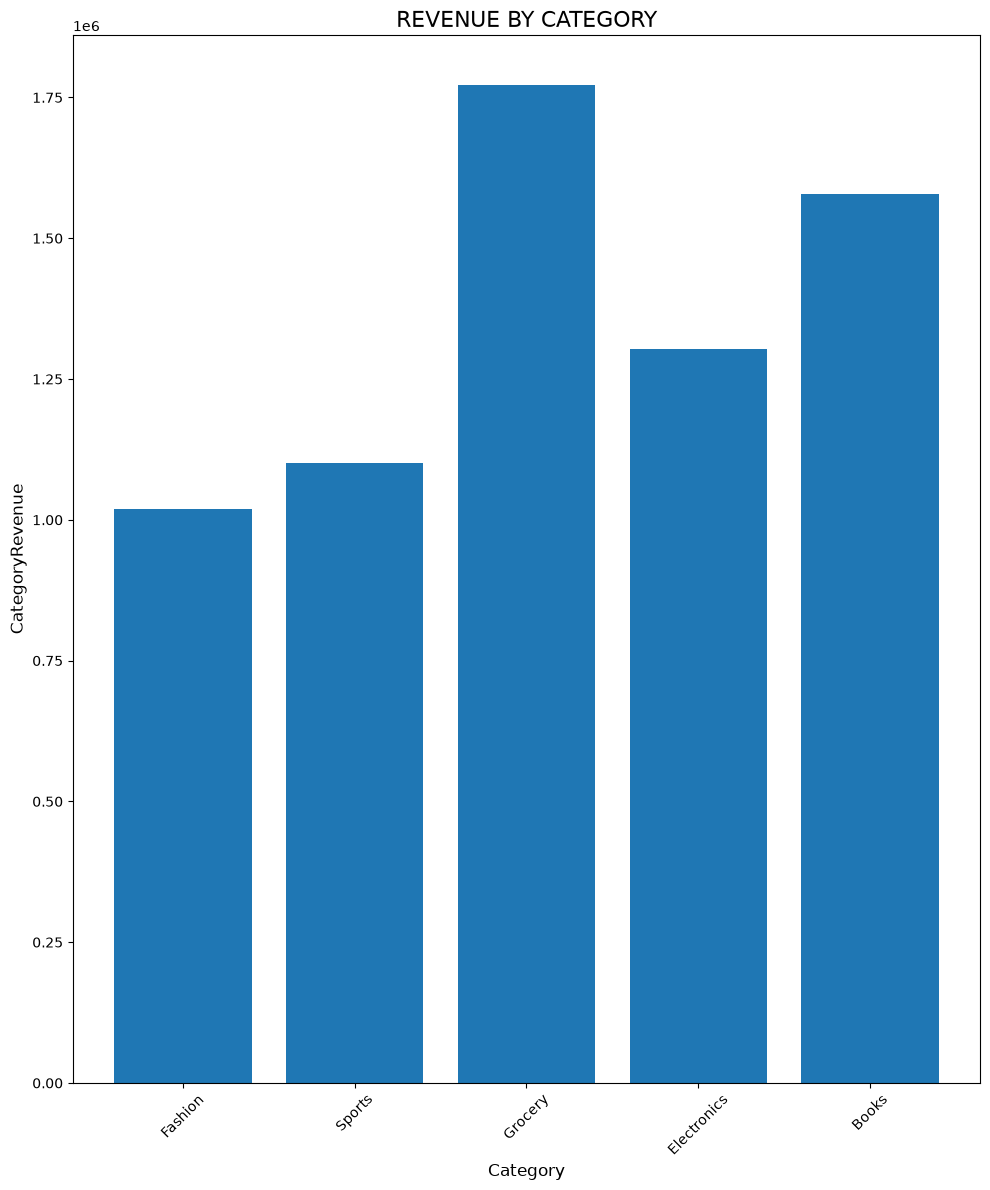

In [330]:
#Barchart
import matplotlib.pyplot as plt
plt.figure(figsize=(10,12))
plt.bar(
    category_pd["Category"],
    category_pd["CategoryRevenue"]
)

plt.title("REVENUE BY CATEGORY", fontsize=16)
plt.xlabel("Category",fontsize=12)
plt.ylabel("CategoryRevenue",fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../images/Revenue_by_category.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [284]:
#Revenue by payment method
payment_pd=payment_revenue.toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


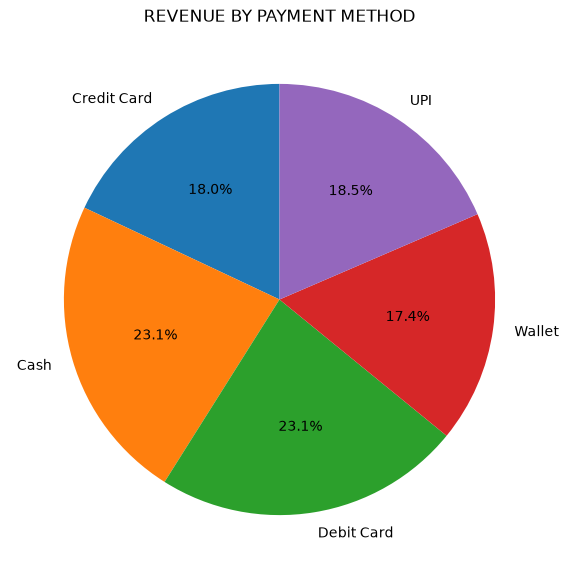

In [327]:
#Piechart

plt.figure(figsize=(7,7))

plt.pie(
    payment_pd["TotalRevenue"],
    labels=payment_pd["PaymentMethod"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("REVENUE BY PAYMENT METHOD")
plt.savefig(
    "../images/Revenue_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [286]:
monthly_pd=month_revenue.toPandas()


c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [287]:
monthly_pd.head()

,Month,MonthName,TotalRevenue
0,1,Jan,832821
1,2,Feb,746584
2,3,Mar,699252
3,4,Apr,933335
4,5,May,924143


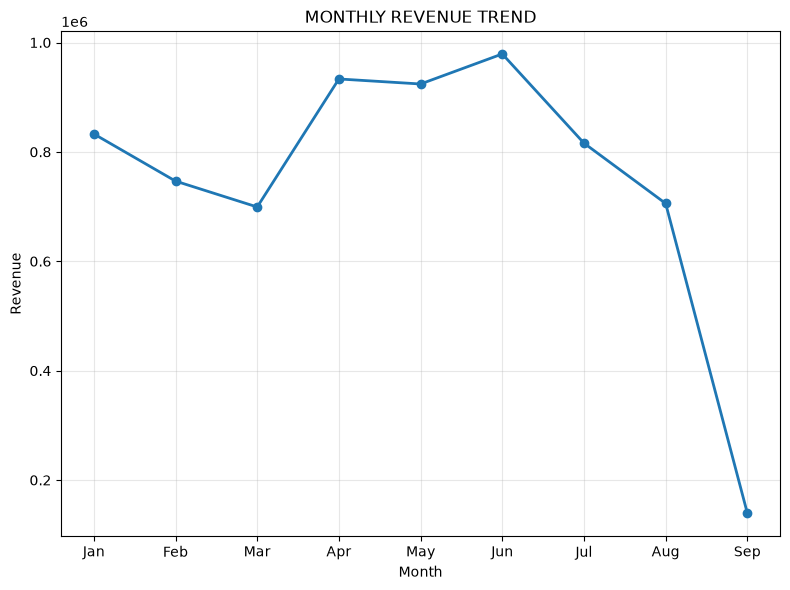

In [320]:
#Line Chart
plt.figure(figsize=(8,6))

plt.plot(
    monthly_pd["MonthName"],
    monthly_pd["TotalRevenue"],
    marker="o",
    linewidth=2

)

plt.title("MONTHLY REVENUE TREND")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/Monthly_Revenue_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [289]:
#Horizontal_bar_chart
#Top 10 Customers by Revenue

top_10.show()

+----------+-------------+------------+
|CustomerID| CustomerName|TotalRevenue|
+----------+-------------+------------+
|      C093| Kiran Gurung|      167901|
|      C091|     Anita KC|      157836|
|      C064|Sabina Gurung|      153289|
|      C058| Aarav Pandey|      141590|
|      C006|Gita Shrestha|      137097|
|      C066|Roshan Gurung|      133102|
|      C062|Ramesh Sharma|      131988|
|      C097|Roshan Pandey|      129030|
|      C070|    Suman Rai|      127967|
|      C029|     Aarav KC|      127762|
+----------+-------------+------------+



In [290]:
top_10_customers_pd=top_10.toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [291]:
top_10_customers_pd.head(10)

,CustomerID,CustomerName,TotalRevenue
0,C093,Kiran Gurung,167901
1,C091,Anita KC,157836
2,C064,Sabina Gurung,153289
3,C058,Aarav Pandey,141590
4,C006,Gita Shrestha,137097
5,C066,Roshan Gurung,133102
6,C062,Ramesh Sharma,131988
7,C097,Roshan Pandey,129030
8,C070,Suman Rai,127967
9,C029,Aarav KC,127762


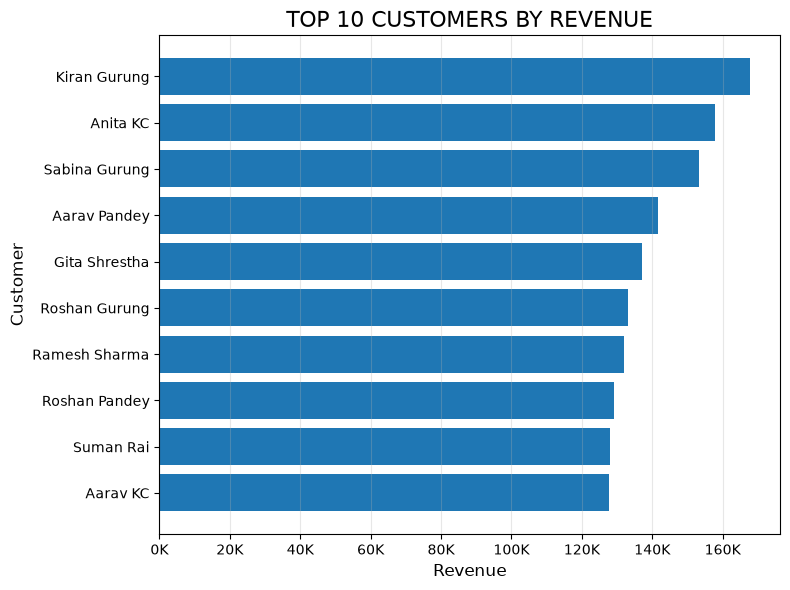

In [321]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(8,6))

plt.barh(   #barh-horizontal bars
    top_10_customers_pd["CustomerName"],
    top_10_customers_pd["TotalRevenue"]
)

plt.title("TOP 10 CUSTOMERS BY REVENUE", fontsize=16)
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Customer", fontsize=12)

plt.gca().invert_yaxis() #plt.gca()-get the current axes,.invert_yaxis()-Puts the highest-revenue customer at the top (instead of the bottom).
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)
plt.grid(axis="x", alpha=0.3)  #Shows only vertical grid lines,-grid(axis="x")
plt.tight_layout()
plt.savefig(
    "../images/Top_10_Customers_By_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [293]:
#Revenue by store
total_revenue_by_store_pd=total_revenue_by_store.toPandas()


c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [294]:
total_revenue_by_store_pd.head()

,StoreID,StoreName,TotalRevenue
0,S015,Store15,469657
1,S006,Store6,465709
2,S005,Store5,461109
3,S017,Store17,448047
4,S010,Store10,447614


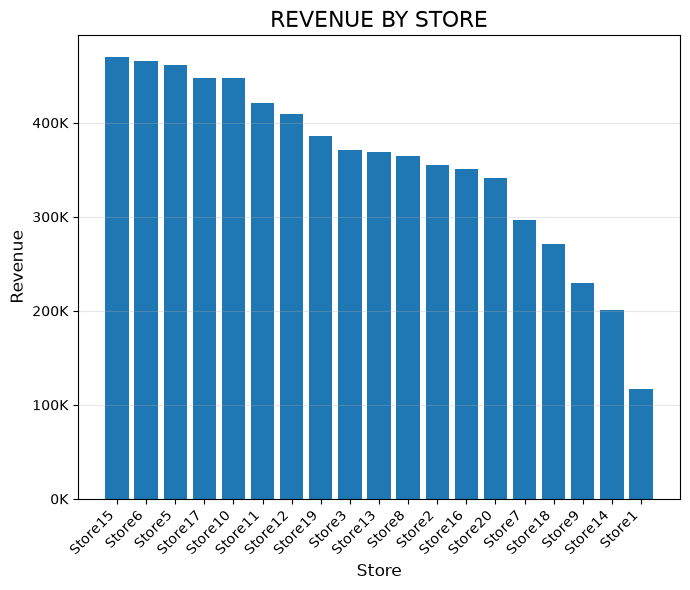

In [333]:
plt.figure(figsize=(7,6))
plt.bar(
    total_revenue_by_store_pd["StoreName"],
    total_revenue_by_store_pd["TotalRevenue"]
)

plt.title("REVENUE BY STORE", fontsize=16)
plt.xlabel("Store", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45, ha="right") #If store names are long, they won't overlap.,, horizontal_alignment=right,defualt-center
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../images/Revenue_By_Store.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [296]:
top_10_products_pd=top_10_products.toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [297]:
top_10_products_pd.head()

,ProductID,ProductName,TotalRevenue
0,P036,Product36,298944
1,P027,Product27,280228
2,P031,Product31,268871
3,P004,Product4,264252
4,P020,Product20,256308


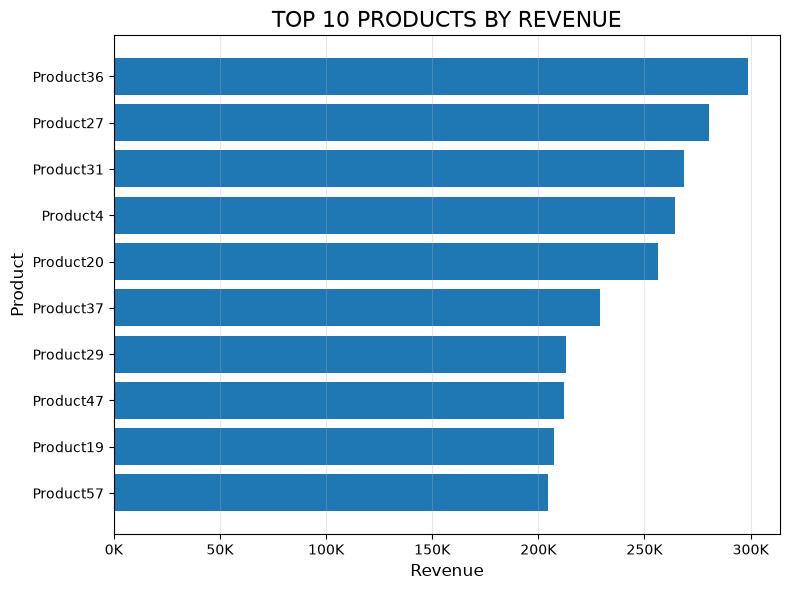

In [323]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,6))

plt.barh(
    top_10_products_pd["ProductName"],
    top_10_products_pd["TotalRevenue"]
)

plt.title("TOP 10 PRODUCTS BY REVENUE", fontsize=16)
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Highest revenue product at the top
plt.gca().invert_yaxis()

# Display revenue in thousands
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../images/Top_10_Products_By_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## VISUALIZATION USING SEABORN


In [ ]:
#Correlation Heatmap
#Correlation tells us how strongly two numerical variables are related.
#import libraries
import seaborn as sns  #creates  statistical visualization
import matplotlib.pyplot as plt  #controls the fig size,title, saving images

In [301]:
corr_df=master_retail_df.select(
    "Revenue",
    "Quantity",
    "Price",
    "CostPrice",
    "Age"

).toPandas()

#correlation works only  on numerical data,seaborn works with pandas df not with spark df so we convert spark df to pandas df and then use seaborn


c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


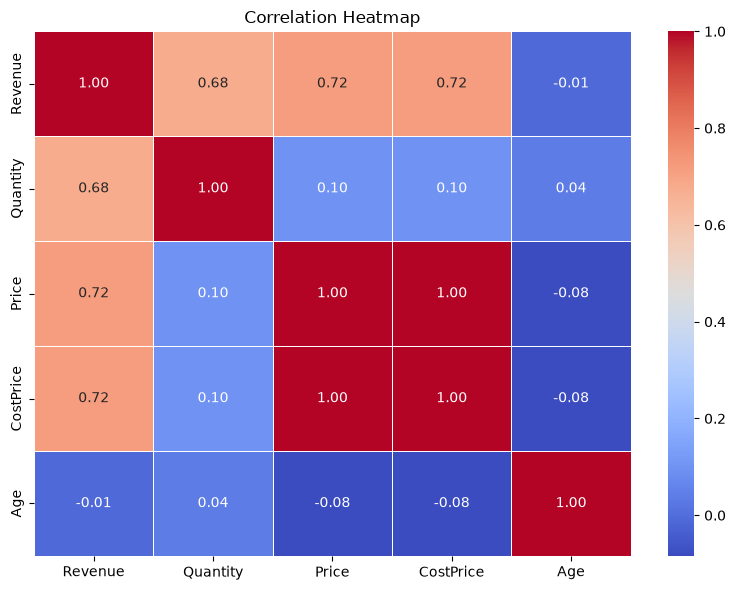

In [ ]:
#create figure
plt.figure(figsize=(8,6))

#Draw heatmap
sns.heatmap(
    corr_df.corr(numeric_only=True), #computes correaltion matrix
    annot=True, #shows num inside box
    cmap="coolwarm", #colour theme,positive cooreleation-warm(reds),negative coorealtion-cool colors(blues)
    linewidths=0.5, #borders between cells
    fmt=".2f" # show upto two decimal values 
)
plt.title("CORRELATION HEATMAP")
plt.tight_layout() #prevents title,labels from being cut off
plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [304]:
#Revenue Distribution (Histogram + KDE)
#Instead of comparing categories or stores, it shows the shape of your data.

revenue_pd=master_retail_df.select("Revenue").toPandas()

c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


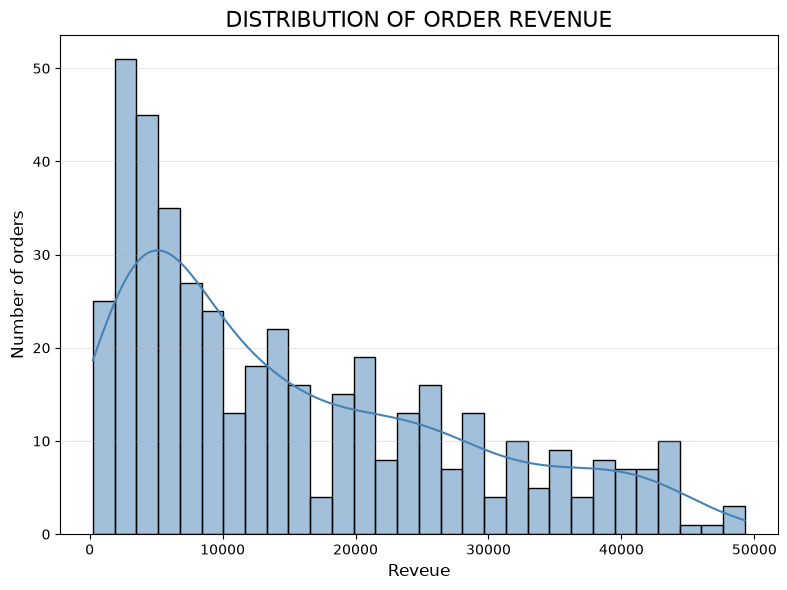

In [324]:
plt.figure(figsize=(8,6))
sns.histplot(
    revenue_pd["Revenue"],
    bins=30, #more groups,more bins-more detail
    kde=True,
    color="steelblue"
)
plt.title("DISTRIBUTION OF ORDER REVENUE", fontsize=16)
plt.xlabel("Reveue", fontsize=12)
plt.ylabel("Number of orders", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../images/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Boxplot-Outlier detection-decides outlier using interquartile range IQR=(Q3-Q1) ,lowerLimit=Q1-1.5*IQR,UpperLimit= Q3+1.5*IQR,anything outside this limit becomes an outliers
#Instead of showing the frequency like a histogram, a box plot summarizes the distribution and highlights outliers.
revenue_pd=master_retail_df.select("Revenue").toPandas()


c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


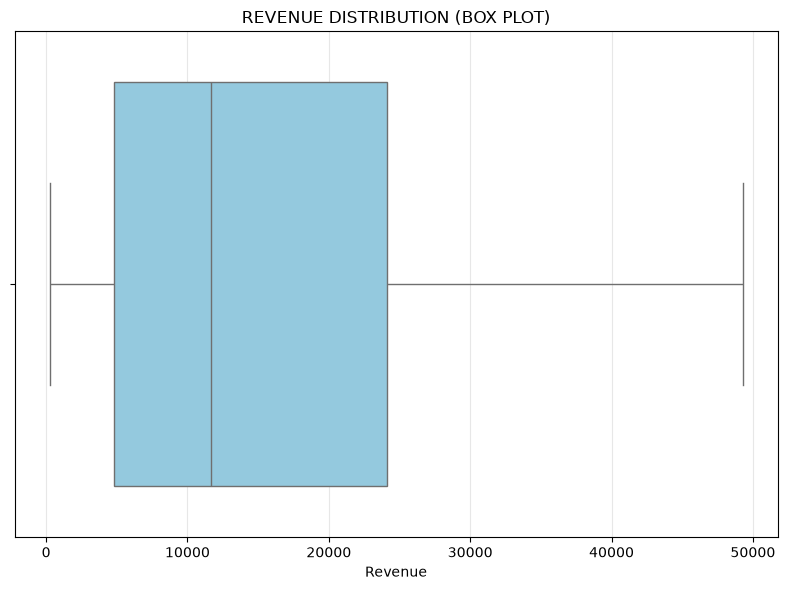

In [325]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=revenue_pd["Revenue"], #horizontal box plot
    color="skyblue"
)

plt.title("REVENUE DISTRIBUTION (BOX PLOT)")
plt.xlabel("Revenue")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../images/revenue_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
#if a boxplot contains several outliers-it indicates that a few order have revenue much higher or lower than majority of orders,these could represent premium purchases,bulk orders or even data quality issues.

In [309]:
#Violin Plot-it combines information from a box plot and a distribution plot.
#How does Revenue vary across different product categories?

revenue_category_pd=master_retail_df.select(
    "Category",
    "Revenue"
).toPandas()



c:\Users\LENOVO\Desktop\RetailSalesAnalytics\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13276\4029598925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


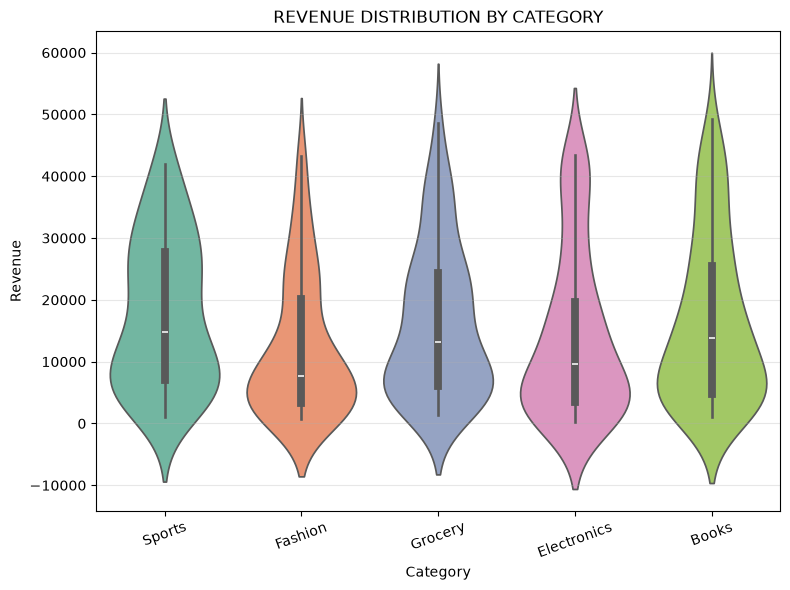

In [326]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=revenue_category_pd,
    x="Category",
    y="Revenue",
    palette="Set2"
)

plt.title("REVENUE DISTRIBUTION BY CATEGORY")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=20)
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/revenue_distribution_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#"The violin plot compares revenue distributions across product categories. 
# It not only summarizes the median and spread of revenue but also reveals the density of observations. 
# Wider regions indicate where most orders are concentrated, making it easier to compare purchasing patterns between categories."